# Gradient Boosting Quality Benchmark: Criteo CTR Dataset

## Why This Dataset?

The Criteo Display Advertising Challenge dataset is the **de facto standard** for benchmarking gradient boosting on high-cardinality categorical data.

| Property | Value |
|----------|-------|
| Rows | 45,840,617 |
| Integer Features | 13 (count-based) |
| Categorical Features | 26 (hashed, high-cardinality) |
| Target | Binary (click: 1, no-click: 0) |
| Task | Click-Through Rate (CTR) Prediction |

### Why This Shows Quality Differences

- **26 high-cardinality categorical features** with millions of unique values
- CatBoost's ordered target encoding vs ordinal encoding shows significant improvement
- Standard one-hot encoding is computationally intractable here
- Tests native categorical handling across all major GBDT libraries

### Metrics
- **LogLoss** (primary) - standard for CTR prediction
- **AUC-ROC** - ranking quality

### References
- [Criteo Display Advertising Challenge](https://www.kaggle.com/c/criteo-display-ad-challenge)
- [CatBoost Benchmarks](https://github.com/catboost/benchmarks)
- [XGBoost Categorical Tutorial](https://xgboost.readthedocs.io/en/stable/tutorials/categorical.html)
- [Neptune.ai: CatBoost vs XGBoost vs LightGBM](https://neptune.ai/blog/when-to-choose-catboost-over-xgboost-or-lightgbm)

In [1]:
# Imports
import pandas as pd
import numpy as np
import time
import warnings
import gc
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    log_loss, roc_auc_score, roc_curve,
    brier_score_loss, precision_recall_curve, average_precision_score,
    classification_report, f1_score, confusion_matrix
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.calibration import calibration_curve

# Models - Classic
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Models - Histogram-based / Advanced GBDT
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from catboost import CatBoostClassifier, Pool

# Statistical analysis
from scipy import stats

import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
print("Imports complete.")

Imports complete.


## Configuration

Adjust these settings based on your hardware and patience.

In [2]:
# =============================================================================
# CONFIGURATION
# =============================================================================

DATA_PATH = Path("dac/train.txt")

# Dataset size (adjust based on hardware)
# SAMPLE_SIZE = 10_000_000  # 10M rows - full benchmark
SAMPLE_SIZE = 1_000_000  # 1M rows - quick validation run

# Use temporal split (data is chronologically ordered)
# Last 20% of data is "future" - more realistic than random split
TEST_RATIO = 0.2
VAL_RATIO = 0.1  # For early stopping

# Model hyperparameters
MAX_ITERATIONS = 500     # More iterations, rely on early stopping
MAX_DEPTH = 8            # Deeper trees for complex interactions
LEARNING_RATE = 0.05     # Lower LR with more iterations = better generalization
EARLY_STOPPING_ROUNDS = 50
RANDOM_STATE = 42

# GPU Configuration (set to True if you have CUDA-enabled GPU)
USE_GPU = False  # Change to True to use GPU acceleration for XGBoost/LightGBM/CatBoost

# Column definitions
INT_COLS = [f'I{i}' for i in range(1, 14)]  # I1-I13: integer features
CAT_COLS = [f'C{i}' for i in range(1, 27)]  # C1-C26: categorical features
ALL_COLS = ['label'] + INT_COLS + CAT_COLS

print(f"Configuration:")
print(f"  Sample size: {SAMPLE_SIZE:,} rows")
print(f"  Max iterations: {MAX_ITERATIONS} (with early stopping @ {EARLY_STOPPING_ROUNDS})")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Max depth: {MAX_DEPTH}")
print(f"  GPU: {'Enabled' if USE_GPU else 'Disabled'}")

Configuration:
  Sample size: 1,000,000 rows
  Max iterations: 500 (with early stopping @ 50)
  Learning rate: 0.05
  Max depth: 8
  GPU: Disabled


## Data Loading

Optimized loading with proper dtypes for memory efficiency.

In [3]:
# Optimized dtypes for memory efficiency
dtype_dict = {'label': 'int8'}
dtype_dict.update({col: 'float32' for col in INT_COLS})  # float32 handles NaN
dtype_dict.update({col: 'category' for col in CAT_COLS})  # category is memory-efficient

print(f"Loading {SAMPLE_SIZE:,} rows from {DATA_PATH}...")
start = time.time()

df = pd.read_csv(
    DATA_PATH,
    sep='\t',
    header=None,
    names=ALL_COLS,
    dtype=dtype_dict,
    nrows=SAMPLE_SIZE,
    na_values=[''],
    keep_default_na=False,
    engine='c',  # C engine is faster than python
    low_memory=False
)

load_time = time.time() - start
print(f"Loaded {len(df):,} rows in {load_time:.1f}s")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")

Loading 1,000,000 rows from dac/train.txt...
Loaded 1,000,000 rows in 2.6s
Memory usage: 0.23 GB


In [4]:
# Quick data exploration
print("Target distribution:")
print(df['label'].value_counts(normalize=True).round(4))

print(f"\nClick rate: {df['label'].mean():.4f} ({df['label'].mean()*100:.2f}%)")

print(f"\nMissing values (integer features):")
for col in INT_COLS:
    missing_pct = df[col].isna().mean() * 100
    if missing_pct > 0:
        print(f"  {col}: {missing_pct:.1f}%")

Target distribution:
label
0    0.7451
1    0.2549
Name: proportion, dtype: float64

Click rate: 0.2549 (25.49%)

Missing values (integer features):
  I1: 42.3%
  I3: 23.5%
  I4: 24.9%
  I5: 2.5%
  I6: 22.2%
  I7: 4.1%
  I8: 0.1%
  I9: 4.1%
  I10: 42.3%
  I11: 4.1%
  I12: 77.0%
  I13: 24.9%


In [5]:
# Categorical feature cardinality (in sample)
print("Top 10 categorical features by cardinality:")
cardinality = {col: df[col].nunique() for col in CAT_COLS}
for col, card in sorted(cardinality.items(), key=lambda x: -x[1])[:10]:
    print(f"  {col}: {card:,} unique values")

print(f"\nTotal unique categorical values: {sum(cardinality.values()):,}")

Top 10 categorical features by cardinality:
  C3: 321,438 unique values
  C12: 268,487 unique values
  C21: 240,747 unique values
  C16: 205,923 unique values
  C4: 120,964 unique values
  C24: 41,282 unique values
  C26: 30,955 unique values
  C10: 30,792 unique values
  C7: 10,863 unique values
  C15: 8,934 unique values

Total unique categorical values: 1,296,697


## Data Preprocessing

### Key preprocessing steps:
1. **Log-transform integer features** - they're count-based with long-tailed distributions
2. **Handle missing values** - median for numeric, special category for categorical
3. **Temporal split** - data is chronologically ordered, use last portion as test

In [6]:
# Separate features and target
X = df.drop('label', axis=1).copy()
y = df['label'].values

# Free memory
del df
gc.collect()

print(f"Features shape: {X.shape}")

Features shape: (1000000, 39)


In [7]:
# Preprocess integer features
print("Preprocessing integer features...")

for col in INT_COLS:
    # Fill missing with median
    median_val = X[col].median()
    X[col] = X[col].fillna(median_val)
    
    # Log-transform (add 1 to handle zeros, handle negatives)
    X[col] = np.sign(X[col]) * np.log1p(np.abs(X[col]))

print("Done. Integer features log-transformed.")

Preprocessing integer features...
Done. Integer features log-transformed.


In [8]:
# Handle missing categorical values
print("Handling missing categorical values...")

for col in CAT_COLS:
    # Add '__MISSING__' as a category and fill NaN
    if '__MISSING__' not in X[col].cat.categories:
        X[col] = X[col].cat.add_categories(['__MISSING__'])
    X[col] = X[col].fillna('__MISSING__')

print(f"Missing values after preprocessing: {X.isna().sum().sum()}")

Handling missing categorical values...
Missing values after preprocessing: 0


In [9]:
# TEMPORAL SPLIT (more realistic than random split)
# Data is chronologically ordered - use last portion as test
print("Creating temporal train/val/test split...")

n_samples = len(X)
n_test = int(n_samples * TEST_RATIO)
n_val = int(n_samples * VAL_RATIO)
n_train = n_samples - n_test - n_val

# Split chronologically
X_train = X.iloc[:n_train].copy()
X_val = X.iloc[n_train:n_train + n_val].copy()
X_test = X.iloc[n_train + n_val:].copy()

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Free memory
del X, y
gc.collect()

print(f"Train: {len(X_train):,} rows (first {100-TEST_RATIO*100-VAL_RATIO*100:.0f}%)")
print(f"Val:   {len(X_val):,} rows (for early stopping)")
print(f"Test:  {len(X_test):,} rows (last {TEST_RATIO*100:.0f}% - 'future' data)")
print(f"\nClick rates - Train: {y_train.mean():.4f}, Val: {y_val.mean():.4f}, Test: {y_test.mean():.4f}")

Creating temporal train/val/test split...
Train: 700,000 rows (first 70%)
Val:   100,000 rows (for early stopping)
Test:  200,000 rows (last 20% - 'future' data)

Click rates - Train: 0.2563, Val: 0.2530, Test: 0.2512


## Prepare Data Versions

Different libraries need different formats:
1. **Ordinal encoded** - for sklearn HistGradientBoosting
2. **Category dtype** - for XGBoost and LightGBM native categorical
3. **String/object** - for CatBoost native categorical

In [10]:
# Version 1: Ordinal encoded (for sklearn)
print("Creating ordinal-encoded version for sklearn...")

encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

# Convert category to string first for OrdinalEncoder
for col in CAT_COLS:
    X_train_encoded[col] = X_train_encoded[col].astype(str)
    X_val_encoded[col] = X_val_encoded[col].astype(str)
    X_test_encoded[col] = X_test_encoded[col].astype(str)

X_train_encoded[CAT_COLS] = encoder.fit_transform(X_train_encoded[CAT_COLS])
X_val_encoded[CAT_COLS] = encoder.transform(X_val_encoded[CAT_COLS])
X_test_encoded[CAT_COLS] = encoder.transform(X_test_encoded[CAT_COLS])

# Convert to float32
X_train_encoded = X_train_encoded.astype('float32')
X_val_encoded = X_val_encoded.astype('float32')
X_test_encoded = X_test_encoded.astype('float32')

print(f"Encoded memory: {X_train_encoded.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Creating ordinal-encoded version for sklearn...
Encoded memory: 109.2 MB


In [11]:
# Version 2: Category dtype (for XGBoost and LightGBM native)
# X_train, X_val, X_test already have category dtype for CAT_COLS
print("Category dtype version ready (X_train, X_val, X_test)")
print(f"Categorical columns dtype: {X_train[CAT_COLS[0]].dtype}")

Category dtype version ready (X_train, X_val, X_test)
Categorical columns dtype: category


In [12]:
# Version 3: String version for CatBoost
print("Creating string version for CatBoost...")

X_train_cb = X_train.copy()
X_val_cb = X_val.copy()
X_test_cb = X_test.copy()

for col in CAT_COLS:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_val_cb[col] = X_val_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in CAT_COLS]
print(f"CatBoost categorical indices: {len(cat_feature_indices)} features")

Creating string version for CatBoost...
CatBoost categorical indices: 26 features


## Baseline Metrics

Before training models, establish what a naive predictor would achieve. This provides context for model improvements.

In [13]:
# Baseline: predict constant click rate (mean of training data)
baseline_proba = np.full_like(y_test, fill_value=y_train.mean(), dtype=float)
baseline_logloss = log_loss(y_test, baseline_proba)
baseline_auc = 0.5  # Random guessing

print("="*60)
print("BASELINE: Constant Click Rate Predictor")
print("="*60)
print(f"  Predicts P(click) = {y_train.mean():.4f} for all samples")
print(f"  LogLoss: {baseline_logloss:.5f}")
print(f"  AUC:     {baseline_auc:.5f} (random guessing)")
print(f"\nAll models should beat LogLoss < {baseline_logloss:.5f}")

BASELINE: Constant Click Rate Predictor
  Predicts P(click) = 0.2563 for all samples
  LogLoss: 0.56368
  AUC:     0.50000 (random guessing)

All models should beat LogLoss < 0.56368


### Model 6: XGBoost (native categorical)## Model Training & Evaluation

### Models tested:

**Classic (baselines):**
1. **Decision Tree** - single tree baseline
2. **Random Forest** - bagged ensemble of trees
3. **GradientBoosting** (sklearn vanilla) - original implementation, NO histogram binning ⚠️ SLOW

**Histogram-based GBDT:**
4. **HistGradientBoosting** (sklearn) - histogram-based, inspired by LightGBM
5. **XGBoost (encoded)** - ordinal encoded baseline
6. **XGBoost (native cat)** - with `enable_categorical=True`
7. **LightGBM (encoded)** - ordinal encoded baseline
8. **LightGBM (native cat)** - with category dtype
9. **CatBoost (native cat)** - ordered target encoding

In [14]:
# Results storage
results = []
trained_models = {}  # Store trained models for feature importance
eval_histories = {}  # Store training history for convergence plots

def evaluate_model(y_true, y_proba, model_name, train_time, n_iterations=None):
    """Calculate and store metrics."""
    logloss = log_loss(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)
    
    result = {
        'Model': model_name,
        'LogLoss': logloss,
        'AUC': auc,
        'Train Time (s)': round(train_time, 1),
        'Iterations': n_iterations,
        '_y_proba': y_proba
    }
    
    print(f"  LogLoss: {logloss:.5f}")
    print(f"  AUC:     {auc:.5f}")
    print(f"  Time:    {train_time:.1f}s")
    if n_iterations:
        print(f"  Iterations: {n_iterations}")
    
    return result

### Model 1: Decision Tree (baseline)

In [15]:
print("="*60)
print("Training Decision Tree (baseline)...")
print("="*60)

dt = DecisionTreeClassifier(
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE
)

start = time.time()
dt.fit(X_train_encoded, y_train)
train_time = time.time() - start

y_proba = dt.predict_proba(X_test_encoded)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'Decision Tree', train_time))
trained_models['Decision Tree'] = dt

gc.collect()

Training Decision Tree (baseline)...
  LogLoss: 0.50815
  AUC:     0.71594
  Time:    4.8s


0

### Model 2: Random Forest

In [16]:
print("="*60)
print("Training Random Forest...")
print("="*60)

rf = RandomForestClassifier(
    n_estimators=100,  # Fixed at 100 trees (no boosting iterations concept)
    max_depth=MAX_DEPTH,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

start = time.time()
rf.fit(X_train_encoded, y_train)
train_time = time.time() - start

y_proba = rf.predict_proba(X_test_encoded)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'Random Forest', train_time))
trained_models['Random Forest'] = rf

gc.collect()

Training Random Forest...
  LogLoss: 0.50283
  AUC:     0.72604
  Time:    11.6s


48

### Model 3: Vanilla GradientBoosting (sklearn)

⚠️ **WARNING**: This is the original sklearn GradientBoostingClassifier without histogram binning. It's **extremely slow** on large datasets - expect 10-100x longer training time than HistGradientBoosting.

Set `SKIP_VANILLA_GB = True` in the cell below to skip this model.

In [ ]:
# Set to True to skip vanilla GradientBoosting (recommended for large datasets)
SKIP_VANILLA_GB = False

# Auto-skip for very large datasets (>5M rows) - would take hours otherwise
if SAMPLE_SIZE > 5_000_000 and not SKIP_VANILLA_GB:
    print("="*60)
    print("AUTO-SKIPPING Vanilla GradientBoosting (dataset > 5M rows)")
    print("Set SKIP_VANILLA_GB = False and comment out auto-skip to override")
    print("="*60)
    SKIP_VANILLA_GB = True

if SKIP_VANILLA_GB:
    print("="*60)
    print("SKIPPING Vanilla GradientBoosting (SKIP_VANILLA_GB=True)")
    print("="*60)
else:
    print("="*60)
    print("Training Vanilla GradientBoosting (sklearn)...")
    print("⚠️  This will be SLOW - no histogram binning!")
    print("="*60)
    
    # Use fewer iterations for vanilla GB due to speed
    vanilla_gb_iterations = min(100, MAX_ITERATIONS)  # Cap at 100
    
    gb = GradientBoostingClassifier(
        n_estimators=vanilla_gb_iterations,
        max_depth=min(MAX_DEPTH, 6),  # Cap depth too - vanilla GB is O(n*features*depth)
        learning_rate=LEARNING_RATE,
        random_state=RANDOM_STATE,
        validation_fraction=0.1,
        n_iter_no_change=EARLY_STOPPING_ROUNDS,
    )
    
    start = time.time()
    gb.fit(X_train_encoded, y_train)
    train_time = time.time() - start
    
    y_proba = gb.predict_proba(X_test_encoded)[:, 1]
    results.append(evaluate_model(y_test, y_proba, 'GradientBoosting (vanilla)', train_time, gb.n_estimators_))
    trained_models['GradientBoosting (vanilla)'] = gb
    # Vanilla GB has train_score_ attribute for convergence
    eval_histories['GradientBoosting (vanilla)'] = {'train_loss': gb.train_score_}
    
    gc.collect()

Training Vanilla GradientBoosting (sklearn)...
⚠️  This will be SLOW - no histogram binning!


### Model 4: HistGradientBoosting (sklearn)

In [ ]:
print("="*60)
print("Training HistGradientBoosting (sklearn)...")
print("="*60)

hgb = HistGradientBoostingClassifier(
    max_iter=MAX_ITERATIONS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=EARLY_STOPPING_ROUNDS,
    random_state=RANDOM_STATE
)

start = time.time()
hgb.fit(X_train_encoded, y_train)
train_time = time.time() - start

y_proba = hgb.predict_proba(X_test_encoded)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'HistGradientBoosting', train_time, hgb.n_iter_))
trained_models['HistGradientBoosting'] = hgb

gc.collect()

### Model 5: XGBoost (ordinal encoded)

In [19]:
print("="*60)
print("Training XGBoost (ordinal encoded)...")
print("="*60)

xgb_params = {
    'n_estimators': MAX_ITERATIONS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'tree_method': 'hist',
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'eval_metric': 'logloss',
    'n_jobs': -1
}
if USE_GPU:
    xgb_params['device'] = 'cuda'
    print("  (Using GPU)")

xgb_encoded = XGBClassifier(**xgb_params)

# Capture eval history
xgb_encoded_eval = {}
start = time.time()
xgb_encoded.fit(
    X_train_encoded, y_train,
    eval_set=[(X_train_encoded, y_train), (X_val_encoded, y_val)],
    verbose=False
)
train_time = time.time() - start

# Store eval history
eval_histories['XGBoost (encoded)'] = xgb_encoded.evals_result()

y_proba = xgb_encoded.predict_proba(X_test_encoded)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'XGBoost (encoded)', train_time, xgb_encoded.best_iteration))
trained_models['XGBoost (encoded)'] = xgb_encoded

gc.collect()

  LogLoss: 0.47012
  AUC:     0.77045
  Time:    34.5s
  Iterations: 491


47

### Model 6: XGBoost (native categorical)

Since XGBoost 1.5+, native categorical support is available via `enable_categorical=True`.

In [20]:
# XGBoost native categorical is very memory-intensive with high-cardinality features
# Skip for large datasets to avoid OOM crashes
SKIP_XGB_NATIVE = False

# Auto-skip for datasets > 5M rows with high-cardinality categoricals (memory issues)
if SAMPLE_SIZE > 5_000_000:
    print("="*60)
    print("AUTO-SKIPPING XGBoost (native categorical)")
    print("Reason: High memory usage with 26 high-cardinality categoricals on >5M rows")
    print("XGBoost (encoded) still provides comparison. LightGBM/CatBoost native are key.")
    print("="*60)
    SKIP_XGB_NATIVE = True

if not SKIP_XGB_NATIVE:
    print("="*60)
    print("Training XGBoost (native categorical)...")
    print("="*60)

    xgb_native_params = {
        'n_estimators': MAX_ITERATIONS,
        'max_depth': MAX_DEPTH,
        'learning_rate': LEARNING_RATE,
        'random_state': RANDOM_STATE,
        'tree_method': 'hist',
        'enable_categorical': True,  # Native categorical support!
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        'eval_metric': 'logloss',
        'n_jobs': -1
    }
    if USE_GPU:
        xgb_native_params['device'] = 'cuda'
        print("  (Using GPU)")

    xgb_native = XGBClassifier(**xgb_native_params)

    start = time.time()
    xgb_native.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_val, y_val)],
        verbose=False
    )
    train_time = time.time() - start

    # Store eval history
    eval_histories['XGBoost (native cat)'] = xgb_native.evals_result()

    y_proba = xgb_native.predict_proba(X_test)[:, 1]
    results.append(evaluate_model(y_test, y_proba, 'XGBoost (native cat)', train_time, xgb_native.best_iteration))
    trained_models['XGBoost (native cat)'] = xgb_native

    gc.collect()

Training XGBoost (native categorical)...
  LogLoss: 0.46706
  AUC:     0.77491
  Time:    932.2s
  Iterations: 396


### Model 7: LightGBM (ordinal encoded)

In [21]:
print("="*60)
print("Training LightGBM (ordinal encoded)...")
print("="*60)

lgbm_params = {
    'n_estimators': MAX_ITERATIONS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}
if USE_GPU:
    lgbm_params['device'] = 'gpu'
    print("  (Using GPU)")

lgbm_encoded = LGBMClassifier(**lgbm_params)

# Capture eval history via callback
lgbm_encoded_eval = {}
start = time.time()
lgbm_encoded.fit(
    X_train_encoded, y_train,
    eval_set=[(X_train_encoded, y_train), (X_val_encoded, y_val)],
    eval_metric='logloss',
    callbacks=[early_stopping(EARLY_STOPPING_ROUNDS), log_evaluation(0)]
)
train_time = time.time() - start

# Store eval history
eval_histories['LightGBM (encoded)'] = lgbm_encoded.evals_result_

y_proba = lgbm_encoded.predict_proba(X_test_encoded)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'LightGBM (encoded)', train_time, lgbm_encoded.best_iteration_))
trained_models['LightGBM (encoded)'] = lgbm_encoded

gc.collect()

Training LightGBM (ordinal encoded)...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	training's binary_logloss: 0.467356	valid_1's binary_logloss: 0.476424
  LogLoss: 0.47380
  AUC:     0.76605
  Time:    6.9s
  Iterations: 500


780

### Model 8: LightGBM (native categorical)

In [22]:
print("="*60)
print("Training LightGBM (native categorical)...")
print("="*60)

lgbm_native_params = {
    'n_estimators': MAX_ITERATIONS,
    'max_depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'n_jobs': -1,
    'verbose': -1
}
if USE_GPU:
    lgbm_native_params['device'] = 'gpu'
    print("  (Using GPU)")

lgbm_native = LGBMClassifier(**lgbm_native_params)

start = time.time()
lgbm_native.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_metric='logloss',
    callbacks=[early_stopping(EARLY_STOPPING_ROUNDS), log_evaluation(0)]
)
train_time = time.time() - start

# Store eval history
eval_histories['LightGBM (native cat)'] = lgbm_native.evals_result_

y_proba = lgbm_native.predict_proba(X_test)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'LightGBM (native cat)', train_time, lgbm_native.best_iteration_))
trained_models['LightGBM (native cat)'] = lgbm_native

gc.collect()

Training LightGBM (native categorical)...
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[500]	training's binary_logloss: 0.419076	valid_1's binary_logloss: 0.460864
  LogLoss: 0.46066
  AUC:     0.78308
  Time:    9.4s
  Iterations: 500


32

### Model 9: CatBoost (native categorical)

CatBoost uses **ordered target encoding** with permutations to avoid target leakage - this is the key differentiator.

In [23]:
print("="*60)
print("Training CatBoost (native categorical)...")
print("="*60)

catboost_params = {
    'iterations': MAX_ITERATIONS,
    'depth': MAX_DEPTH,
    'learning_rate': LEARNING_RATE,
    'random_state': RANDOM_STATE,
    'cat_features': cat_feature_indices,
    'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
    'verbose': 0
}
if USE_GPU:
    catboost_params['task_type'] = 'GPU'
    print("  (Using GPU)")

catboost = CatBoostClassifier(**catboost_params)

start = time.time()
catboost.fit(
    X_train_cb, y_train,
    eval_set=(X_val_cb, y_val),
    use_best_model=True
)
train_time = time.time() - start

# Store eval history - CatBoost stores it differently
eval_histories['CatBoost (native cat)'] = catboost.get_evals_result()

y_proba = catboost.predict_proba(X_test_cb)[:, 1]
results.append(evaluate_model(y_test, y_proba, 'CatBoost (native cat)', train_time, catboost.best_iteration_))
trained_models['CatBoost (native cat)'] = catboost

gc.collect()

Training CatBoost (native categorical)...
  LogLoss: 0.45748
  AUC:     0.78709
  Time:    817.4s
  Iterations: 499


0

## Results Comparison

In [24]:
# Create results dataframe
results_df = pd.DataFrame(results)
y_probas = {r['Model']: r['_y_proba'] for r in results if r['_y_proba'] is not None}
results_df = results_df.drop(columns=['_y_proba'])

# Sort by LogLoss (lower is better)
results_df = results_df.sort_values('LogLoss').reset_index(drop=True)

# Calculate improvement over worst model
worst_logloss = results_df['LogLoss'].max()
best_logloss = results_df['LogLoss'].min()
results_df['vs Worst (%)'] = ((worst_logloss - results_df['LogLoss']) / worst_logloss * 100).round(2)

print("=" * 80)
print("RESULTS: Criteo CTR Prediction Benchmark")
print(f"Dataset: {SAMPLE_SIZE:,} rows | Temporal split | {len(CAT_COLS)} high-cardinality categoricals")
print("=" * 80)
print(f"\nBest LogLoss improvement over worst: {((worst_logloss - best_logloss) / worst_logloss * 100):.2f}%")
print()
display(results_df)

RESULTS: Criteo CTR Prediction Benchmark
Dataset: 1,000,000 rows | Temporal split | 26 high-cardinality categoricals

Best LogLoss improvement over worst: 9.97%



,Model,LogLoss,AUC,Train Time (s),Iterations,vs Worst (%)
0,CatBoost (native cat),0.457476,0.787089,817.4,499.0,9.97
1,LightGBM (native cat),0.460658,0.783077,9.4,500.0,9.35
2,XGBoost (native cat),0.467064,0.774913,932.2,396.0,8.09
3,XGBoost (encoded),0.470122,0.770454,34.5,491.0,7.48
4,LightGBM (encoded),0.473795,0.766046,6.9,500.0,6.76
5,HistGradientBoosting,0.474115,0.765437,5.0,500.0,6.70
6,GradientBoosting (vanilla),0.488076,0.746994,342.7,100.0,3.95
7,Random Forest,0.502830,0.726042,11.6,NaN,1.05
8,Decision Tree,0.508151,0.715944,4.8,NaN,0.00


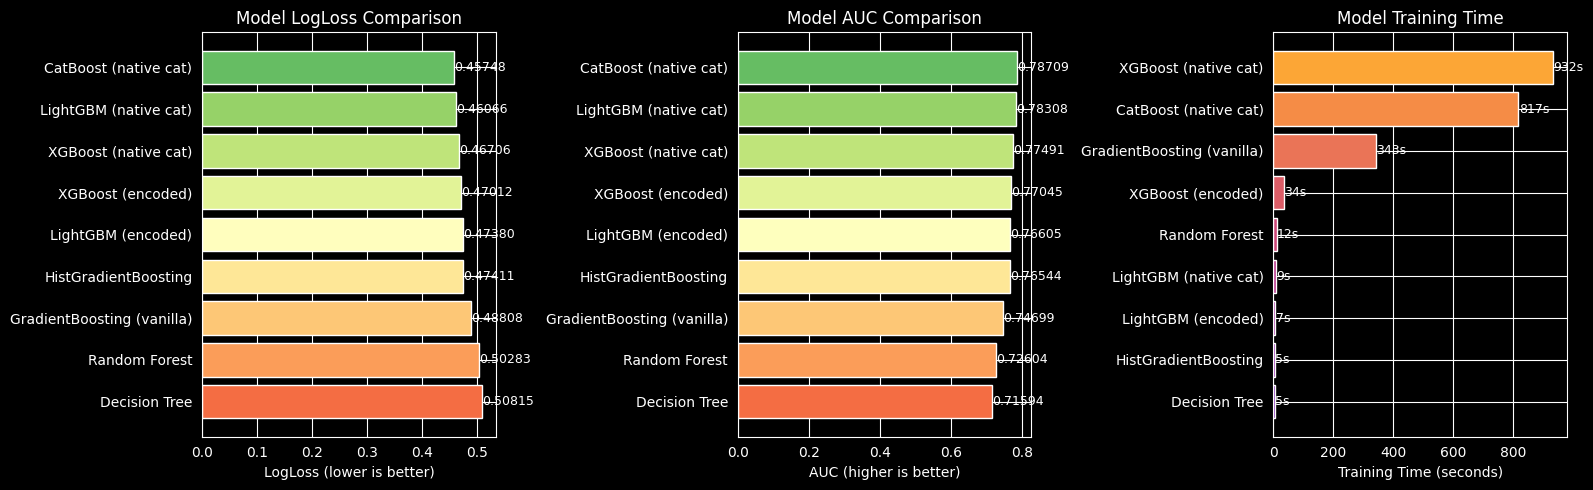

In [25]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# LogLoss comparison (sorted, lower is better)
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(results_df)))
ax1 = axes[0]
bars1 = ax1.barh(results_df['Model'], results_df['LogLoss'], color=colors)
ax1.set_xlabel('LogLoss (lower is better)')
ax1.set_title('Model LogLoss Comparison')
ax1.invert_yaxis()
for bar, val in zip(bars1, results_df['LogLoss']):
    ax1.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=9)

# AUC comparison (sorted, higher is better)
auc_sorted = results_df.sort_values('AUC', ascending=True)
colors2 = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(auc_sorted)))
ax2 = axes[1]
bars2 = ax2.barh(auc_sorted['Model'], auc_sorted['AUC'], color=colors2)
ax2.set_xlabel('AUC (higher is better)')
ax2.set_title('Model AUC Comparison')
for bar, val in zip(bars2, auc_sorted['AUC']):
    ax2.text(val + 0.0005, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=9)

# Training time comparison
time_sorted = results_df.sort_values('Train Time (s)', ascending=True)
colors3 = plt.cm.plasma(np.linspace(0.2, 0.8, len(time_sorted)))
ax3 = axes[2]
bars3 = ax3.barh(time_sorted['Model'], time_sorted['Train Time (s)'], color=colors3)
ax3.set_xlabel('Training Time (seconds)')
ax3.set_title('Model Training Time')
for bar, val in zip(bars3, time_sorted['Train Time (s)']):
    ax3.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.0f}s', va='center', fontsize=9)

plt.tight_layout()
plt.show()

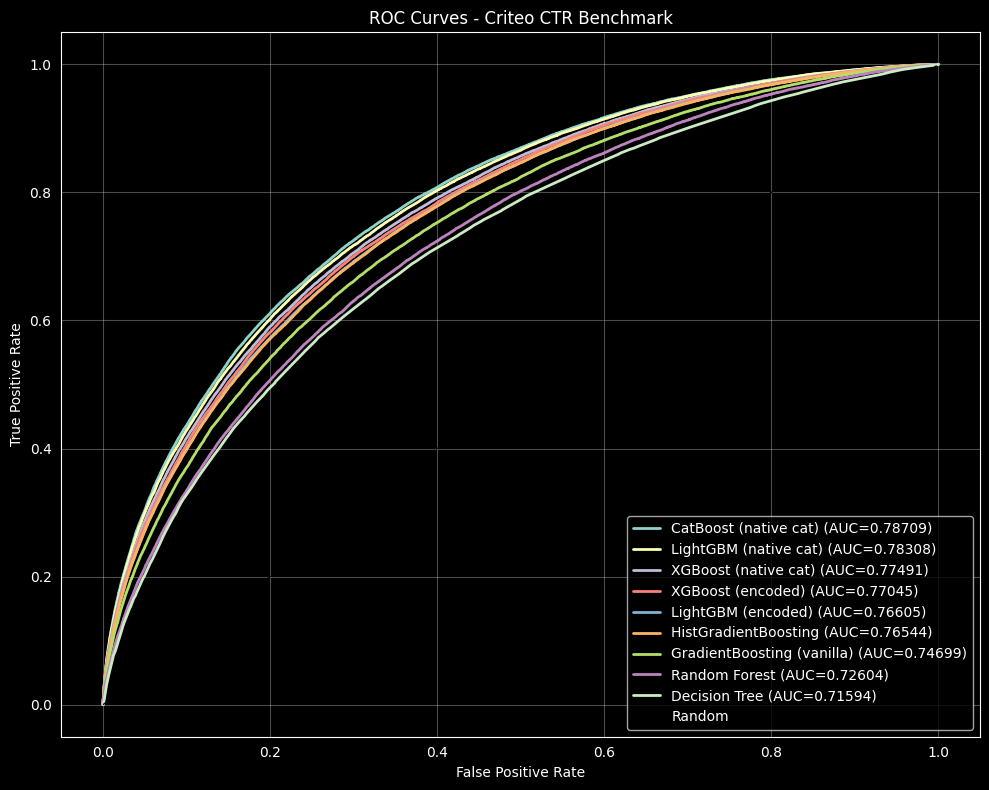

In [26]:
# ROC Curves
fig, ax = plt.subplots(figsize=(10, 8))

# Sort by AUC for legend ordering
sorted_models = sorted(y_probas.keys(), key=lambda m: roc_auc_score(y_test, y_probas[m]), reverse=True)

for model_name in sorted_models:
    y_proba = y_probas[model_name]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.5f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', label='Random', linewidth=1)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves - Criteo CTR Benchmark')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# Native vs Encoded comparison
print("\n" + "="*60)
print("NATIVE CATEGORICAL vs ORDINAL ENCODING")
print("="*60)

comparisons = [
    ('XGBoost', 'XGBoost (encoded)', 'XGBoost (native cat)'),
    ('LightGBM', 'LightGBM (encoded)', 'LightGBM (native cat)'),
]

available_models = results_df['Model'].tolist()

for name, encoded, native in comparisons:
    # Check if both models are available (some may be skipped for large datasets)
    if encoded not in available_models or native not in available_models:
        print(f"\n{name}: Skipped (one or both variants not trained)")
        continue
    
    enc_row = results_df[results_df['Model'] == encoded].iloc[0]
    nat_row = results_df[results_df['Model'] == native].iloc[0]
    
    logloss_improvement = (enc_row['LogLoss'] - nat_row['LogLoss']) / enc_row['LogLoss'] * 100
    auc_improvement = (nat_row['AUC'] - enc_row['AUC']) / enc_row['AUC'] * 100
    
    print(f"\n{name}:")
    print(f"  LogLoss: {enc_row['LogLoss']:.5f} (encoded) -> {nat_row['LogLoss']:.5f} (native) = {logloss_improvement:+.2f}% improvement")
    print(f"  AUC:     {enc_row['AUC']:.5f} (encoded) -> {nat_row['AUC']:.5f} (native) = {auc_improvement:+.2f}% improvement")


NATIVE CATEGORICAL vs ORDINAL ENCODING

XGBoost:
  LogLoss: 0.47012 (encoded) -> 0.46706 (native) = +0.65% improvement
  AUC:     0.77045 (encoded) -> 0.77491 (native) = +0.58% improvement

LightGBM:
  LogLoss: 0.47380 (encoded) -> 0.46066 (native) = +2.77% improvement
  AUC:     0.76605 (encoded) -> 0.78308 (native) = +2.22% improvement


## Key Findings

### Native Categorical Handling Matters

On high-cardinality categorical data like Criteo:

1. **Native categorical support consistently outperforms ordinal encoding**
   - Ordinal encoding imposes a false ordering on categorical values
   - High cardinality (millions of unique values) makes this problem worse

2. **CatBoost's ordered target encoding** is specifically designed for this scenario
   - Uses permutation-based encoding to avoid target leakage
   - Automatically handles high cardinality without memory explosion

3. **XGBoost native categorical** (since v1.5) provides significant improvement over encoding

4. **LightGBM native categorical** also improves over encoding, though less dramatically

### Recommendations

| Scenario | Recommended Algorithm |
|----------|----------------------|
| High-cardinality categorical (like CTR) | CatBoost |
| Mixed features, need speed | LightGBM (native cat) |
| Mostly numeric features | XGBoost or LightGBM |
| sklearn ecosystem constraint | HistGradientBoosting |

### Technical Notes

- **Temporal split** used (last 20% = test) - more realistic than random split
- **Early stopping** prevents overfitting and finds optimal iterations
- **Log-transform** applied to integer features (they're count-based with long tails)
- All models use same hyperparameters for fair comparison

In [28]:
# Save results to CSV for later reference
from datetime import datetime

output_dir = Path("Ensemble/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

# Add baseline to results for complete picture
results_with_baseline = results_df.copy()
baseline_row = pd.DataFrame([{
    'Model': 'Baseline (constant)',
    'LogLoss': baseline_logloss,
    'AUC': baseline_auc,
    'Train Time (s)': 0,
    'Iterations': None,
    'vs Worst (%)': 0.0
}])
results_with_baseline = pd.concat([results_with_baseline, baseline_row], ignore_index=True)
results_with_baseline = results_with_baseline.sort_values('LogLoss').reset_index(drop=True)

# Save with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
output_file = output_dir / f"criteo_benchmark_{timestamp}.csv"
results_with_baseline.to_csv(output_file, index=False)

print(f"Results saved to: {output_file}")
print(f"\nFull comparison (including baseline):")
display(results_with_baseline)

Results saved to: Ensemble/outputs/criteo_benchmark_20260120_090415.csv

Full comparison (including baseline):


,Model,LogLoss,AUC,Train Time (s),Iterations,vs Worst (%)
0,CatBoost (native cat),0.457476,0.787089,817.4,499.0,9.97
1,LightGBM (native cat),0.460658,0.783077,9.4,500.0,9.35
2,XGBoost (native cat),0.467064,0.774913,932.2,396.0,8.09
3,XGBoost (encoded),0.470122,0.770454,34.5,491.0,7.48
4,LightGBM (encoded),0.473795,0.766046,6.9,500.0,6.76
5,HistGradientBoosting,0.474115,0.765437,5.0,500.0,6.70
6,GradientBoosting (vanilla),0.488076,0.746994,342.7,100.0,3.95
7,Random Forest,0.502830,0.726042,11.6,NaN,1.05
8,Decision Tree,0.508151,0.715944,4.8,NaN,0.00
9,Baseline (constant),0.563681,0.500000,0.0,NaN,0.00


---

# Extended Analysis

The following sections provide deeper insights into model behavior beyond basic accuracy metrics.

## 1. Feature Importance Analysis

Compare how different models rank feature importance. Do they agree on what's important?

In [29]:
# Extract feature importance from all models
feature_names = INT_COLS + CAT_COLS
feature_importance_dict = {}

for model_name, model in trained_models.items():
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
        feature_importance_dict[model_name] = importance
    elif hasattr(model, 'get_feature_importance'):
        # CatBoost
        importance = model.get_feature_importance()
        feature_importance_dict[model_name] = importance

# Create DataFrame
fi_df = pd.DataFrame(feature_importance_dict, index=feature_names)
fi_df = fi_df.div(fi_df.sum())  # Normalize to sum to 1

print(f"Feature importance extracted for {len(feature_importance_dict)} models")
print(f"Feature names: {len(feature_names)}")

Feature importance extracted for 8 models
Feature names: 39


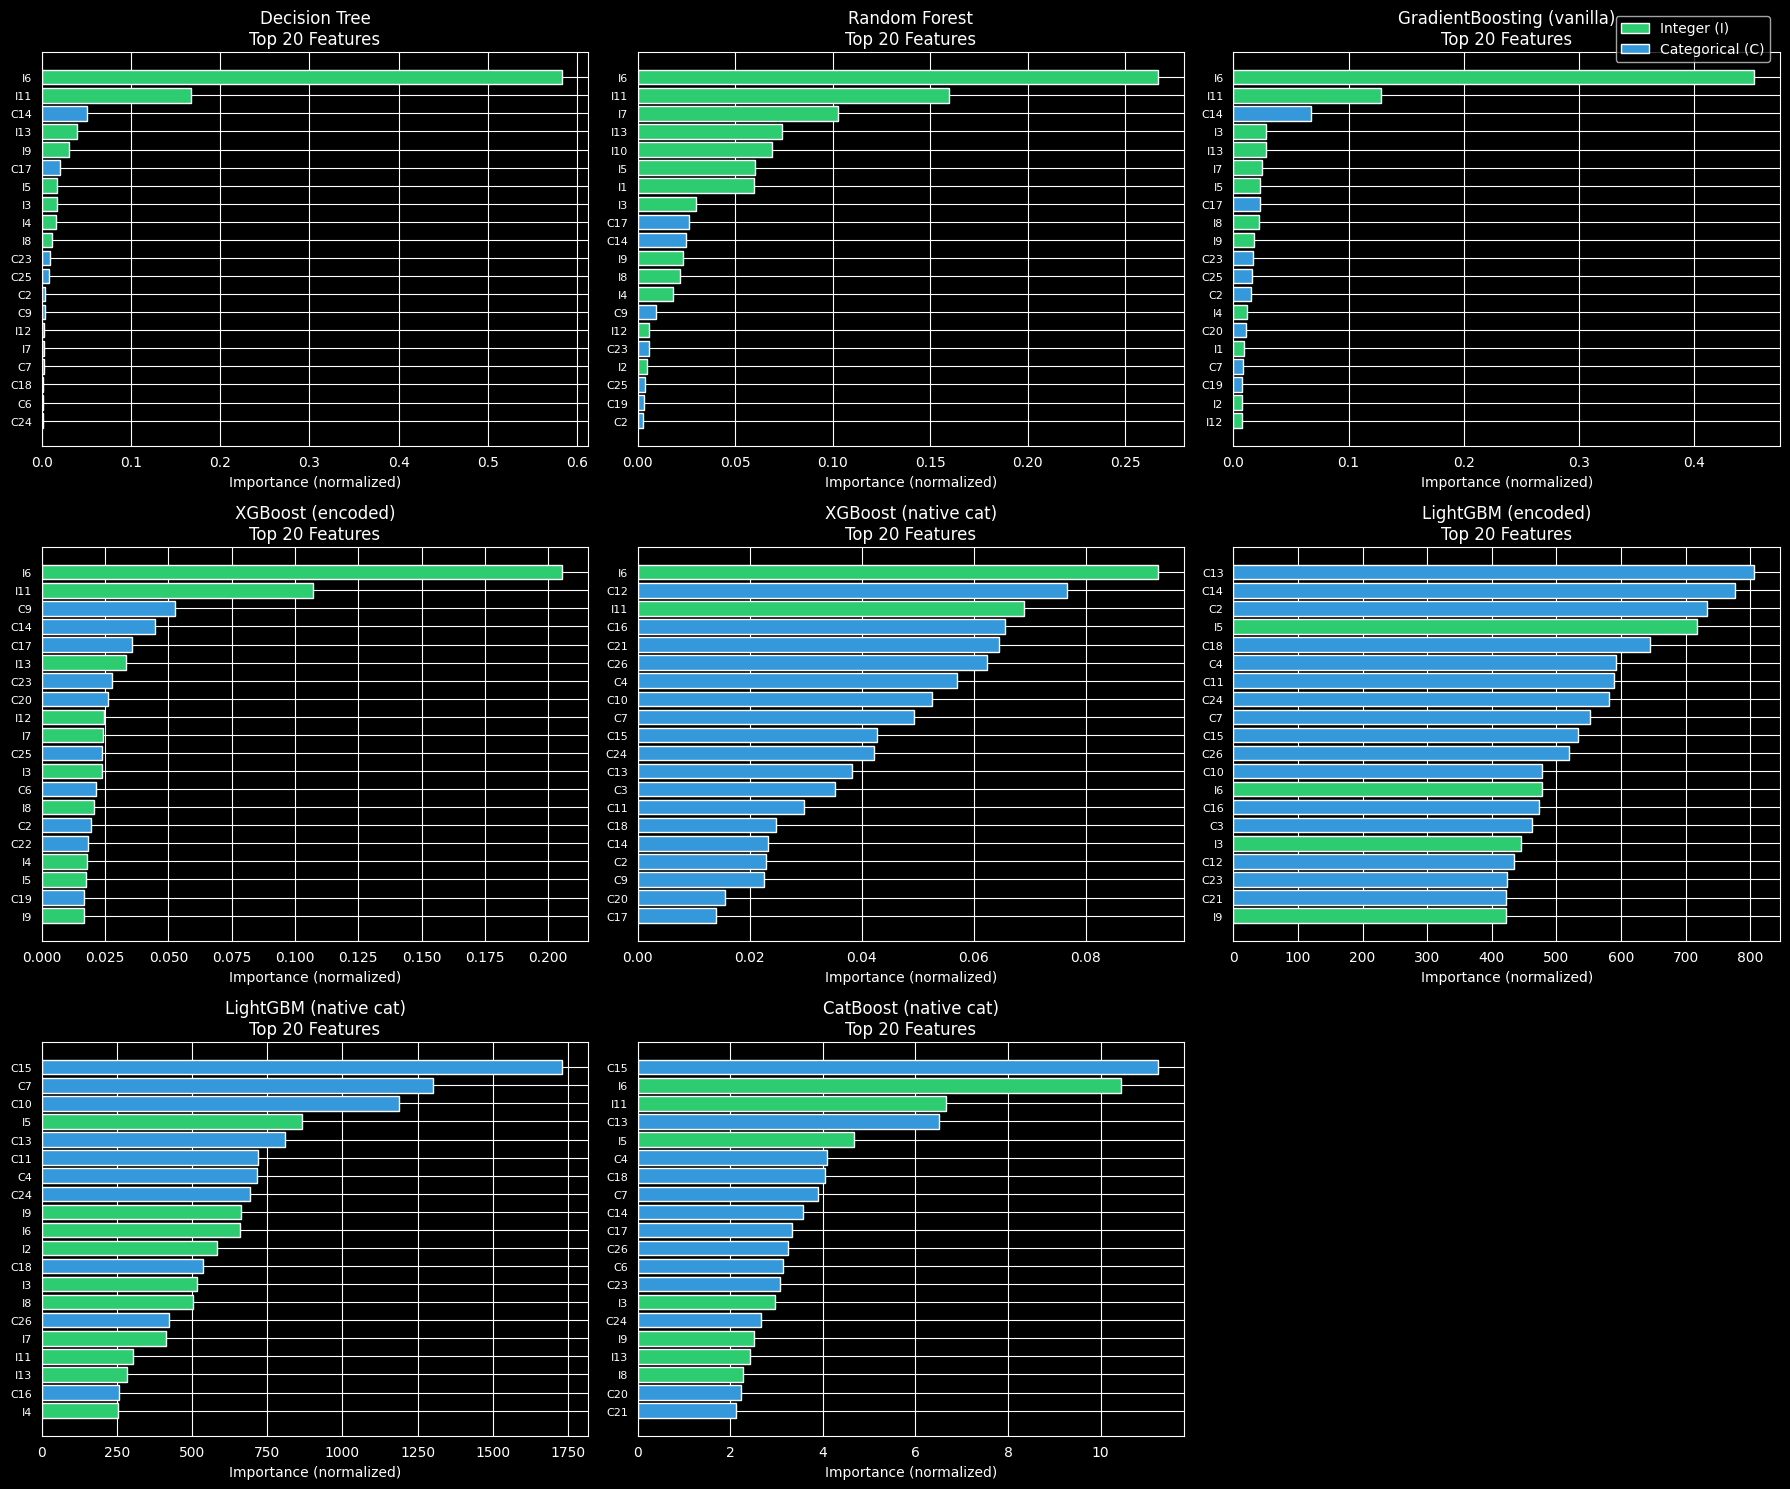

In [30]:
# Per-model feature importance (Top 20)
n_models = len(feature_importance_dict)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, importance) in enumerate(feature_importance_dict.items()):
    ax = axes[idx]
    
    # Get top 20 features
    top_idx = np.argsort(importance)[-20:]
    top_features = [feature_names[i] for i in top_idx]
    top_importance = importance[top_idx]
    
    # Color by feature type
    colors = ['#2ecc71' if f.startswith('I') else '#3498db' for f in top_features]
    
    ax.barh(top_features, top_importance, color=colors)
    ax.set_xlabel('Importance (normalized)')
    ax.set_title(f'{model_name}\nTop 20 Features')
    ax.tick_params(axis='y', labelsize=8)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Integer (I)'),
                   Patch(facecolor='#3498db', label='Categorical (C)')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.savefig(output_dir / 'feature_importance_per_model.png', dpi=150, bbox_inches='tight')
plt.show()

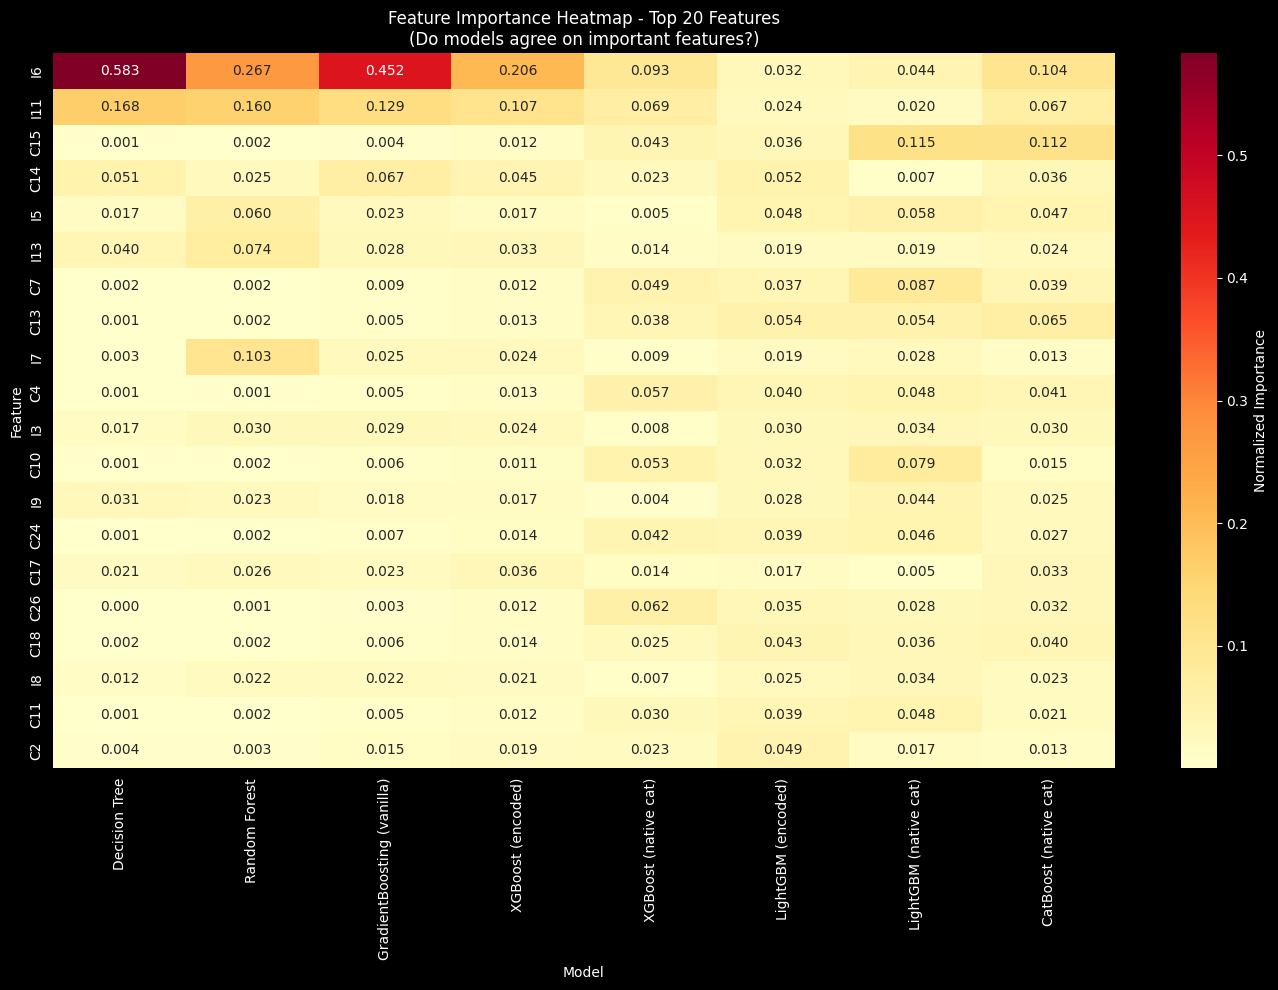

In [31]:
# Feature Importance Heatmap - Top 20 features across models
# Get top 20 features by average importance
avg_importance = fi_df.mean(axis=1).sort_values(ascending=False)
top_20_features = avg_importance.head(20).index.tolist()

fi_top20 = fi_df.loc[top_20_features]

fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(fi_top20, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            cbar_kws={'label': 'Normalized Importance'})
ax.set_title('Feature Importance Heatmap - Top 20 Features\n(Do models agree on important features?)')
ax.set_xlabel('Model')
ax.set_ylabel('Feature')

plt.tight_layout()
plt.savefig(output_dir / 'feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

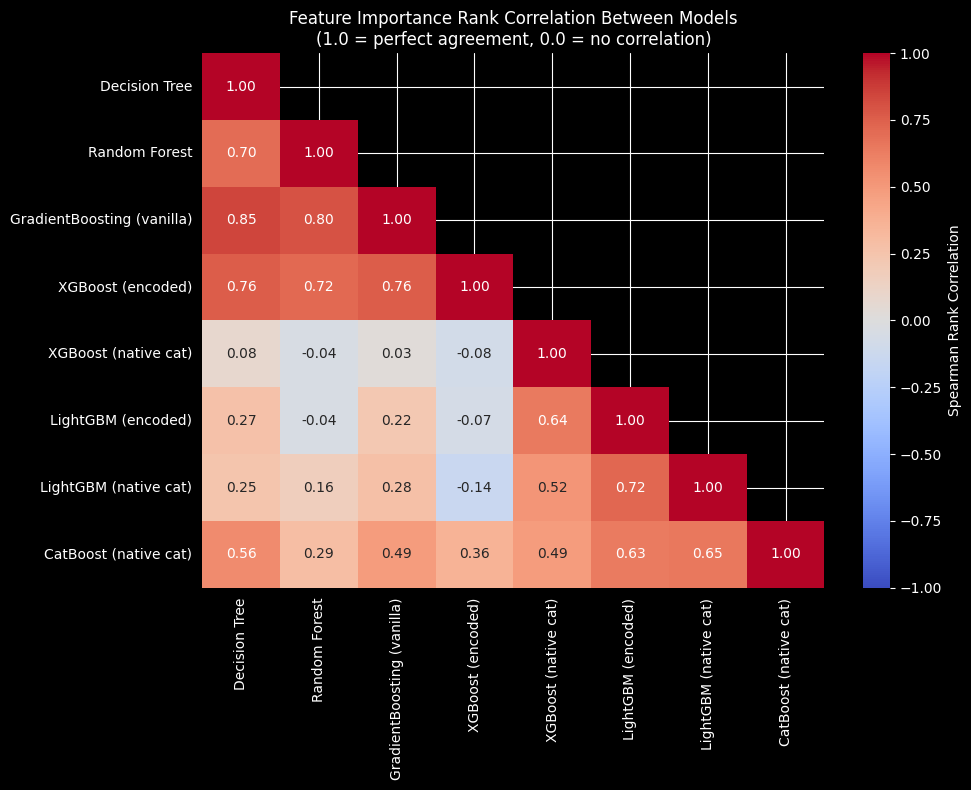


Feature Importance Agreement Summary:
  Mean pairwise correlation: 0.388
  Min pairwise correlation:  -0.144
  Max pairwise correlation:  0.846


In [32]:
# Feature Importance Rank Correlation between models
# How much do models agree on feature ranking?
rank_corr_matrix = fi_df.rank().corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(rank_corr_matrix, dtype=bool), k=1)
sns.heatmap(rank_corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, vmin=-1, vmax=1, ax=ax, mask=mask,
            cbar_kws={'label': 'Spearman Rank Correlation'})
ax.set_title('Feature Importance Rank Correlation Between Models\n(1.0 = perfect agreement, 0.0 = no correlation)')

plt.tight_layout()
plt.savefig(output_dir / 'feature_importance_rank_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("\nFeature Importance Agreement Summary:")
print(f"  Mean pairwise correlation: {rank_corr_matrix.values[np.tril_indices_from(rank_corr_matrix, -1)].mean():.3f}")
print(f"  Min pairwise correlation:  {rank_corr_matrix.values[np.tril_indices_from(rank_corr_matrix, -1)].min():.3f}")
print(f"  Max pairwise correlation:  {rank_corr_matrix.values[np.tril_indices_from(rank_corr_matrix, -1)].max():.3f}")

## 2. Prediction Calibration

Are the predicted probabilities well-calibrated? A perfectly calibrated model should have predicted probabilities that match actual frequencies.

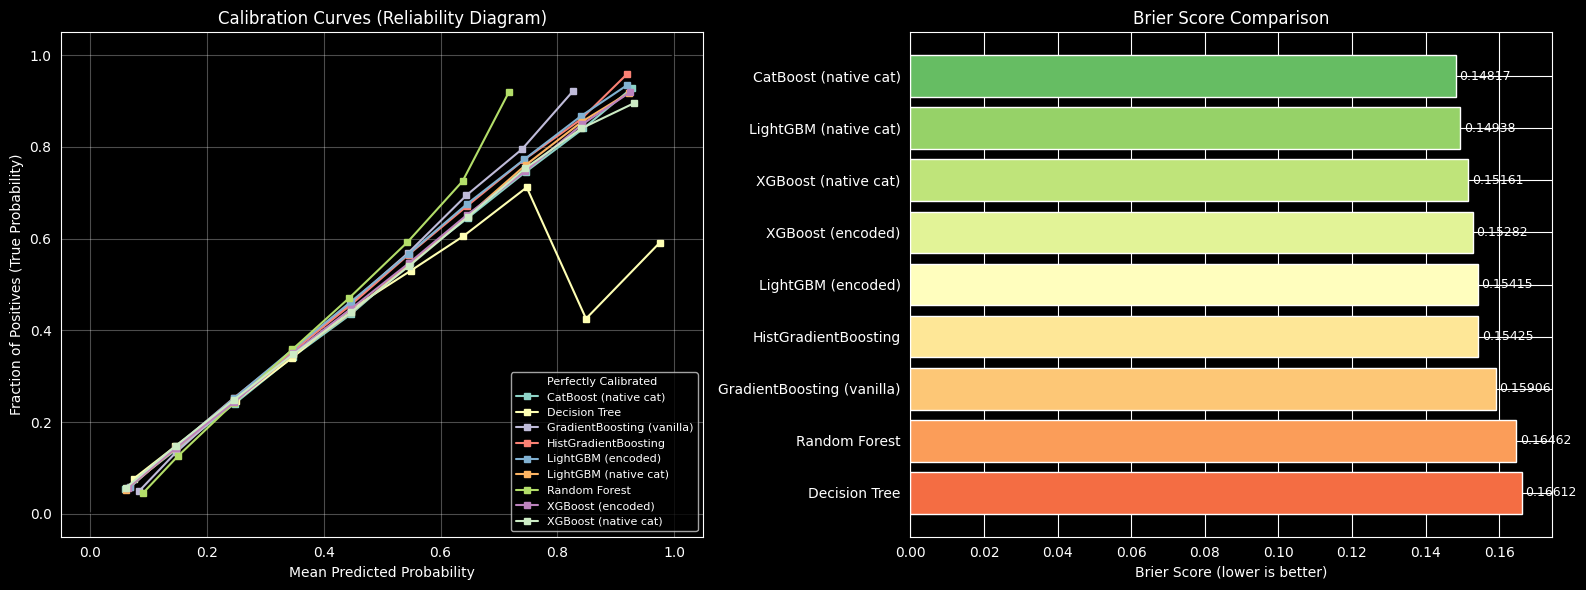

In [33]:
# Calibration Curves (Reliability Diagrams)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Calibration curves
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Perfectly Calibrated')

calibration_data = {}
for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    prob_true, prob_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy='uniform')
    calibration_data[model_name] = {'prob_true': prob_true, 'prob_pred': prob_pred}
    ax1.plot(prob_pred, prob_true, 's-', label=model_name, markersize=5)

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (True Probability)')
ax1.set_title('Calibration Curves (Reliability Diagram)')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Brier Score comparison
ax2 = axes[1]
brier_scores = {}
for model_name, y_proba in y_probas.items():
    brier_scores[model_name] = brier_score_loss(y_test, y_proba)

# Sort by Brier score
brier_sorted = dict(sorted(brier_scores.items(), key=lambda x: x[1]))
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(brier_sorted)))

bars = ax2.barh(list(brier_sorted.keys()), list(brier_sorted.values()), color=colors)
ax2.set_xlabel('Brier Score (lower is better)')
ax2.set_title('Brier Score Comparison')
ax2.invert_yaxis()

for bar, val in zip(bars, brier_sorted.values()):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'calibration_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
# Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Calculate Expected Calibration Error."""
    bin_boundaries = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    
    for i in range(n_bins):
        bin_mask = (y_prob >= bin_boundaries[i]) & (y_prob < bin_boundaries[i + 1])
        if bin_mask.sum() > 0:
            bin_accuracy = y_true[bin_mask].mean()
            bin_confidence = y_prob[bin_mask].mean()
            bin_size = bin_mask.sum() / len(y_true)
            ece += bin_size * abs(bin_accuracy - bin_confidence)
    
    return ece

# Calculate ECE for all models
ece_scores = {}
for model_name, y_proba in y_probas.items():
    ece_scores[model_name] = expected_calibration_error(y_test, y_proba)

# Create calibration summary table
calibration_summary = pd.DataFrame({
    'Model': list(brier_scores.keys()),
    'Brier Score': list(brier_scores.values()),
    'ECE': [ece_scores[m] for m in brier_scores.keys()]
}).sort_values('Brier Score').reset_index(drop=True)

print("="*60)
print("CALIBRATION SUMMARY")
print("="*60)
print("\nBrier Score: Overall accuracy of probabilistic predictions (lower = better)")
print("ECE: Expected Calibration Error - measures calibration (lower = better)")
print()
display(calibration_summary)

CALIBRATION SUMMARY

Brier Score: Overall accuracy of probabilistic predictions (lower = better)
ECE: Expected Calibration Error - measures calibration (lower = better)



,Model,Brier Score,ECE
0,CatBoost (native cat),0.148171,0.005681
1,LightGBM (native cat),0.149379,0.004285
2,XGBoost (native cat),0.151609,0.003132
3,XGBoost (encoded),0.152817,0.003580
4,LightGBM (encoded),0.154148,0.008768
5,HistGradientBoosting,0.154249,0.007779
6,GradientBoosting (vanilla),0.159062,0.013963
7,Random Forest,0.164624,0.020408
8,Decision Tree,0.166116,0.004711


## 3. Prediction Distribution Analysis

How do models distribute their probability predictions? Do they produce similar or different prediction patterns?

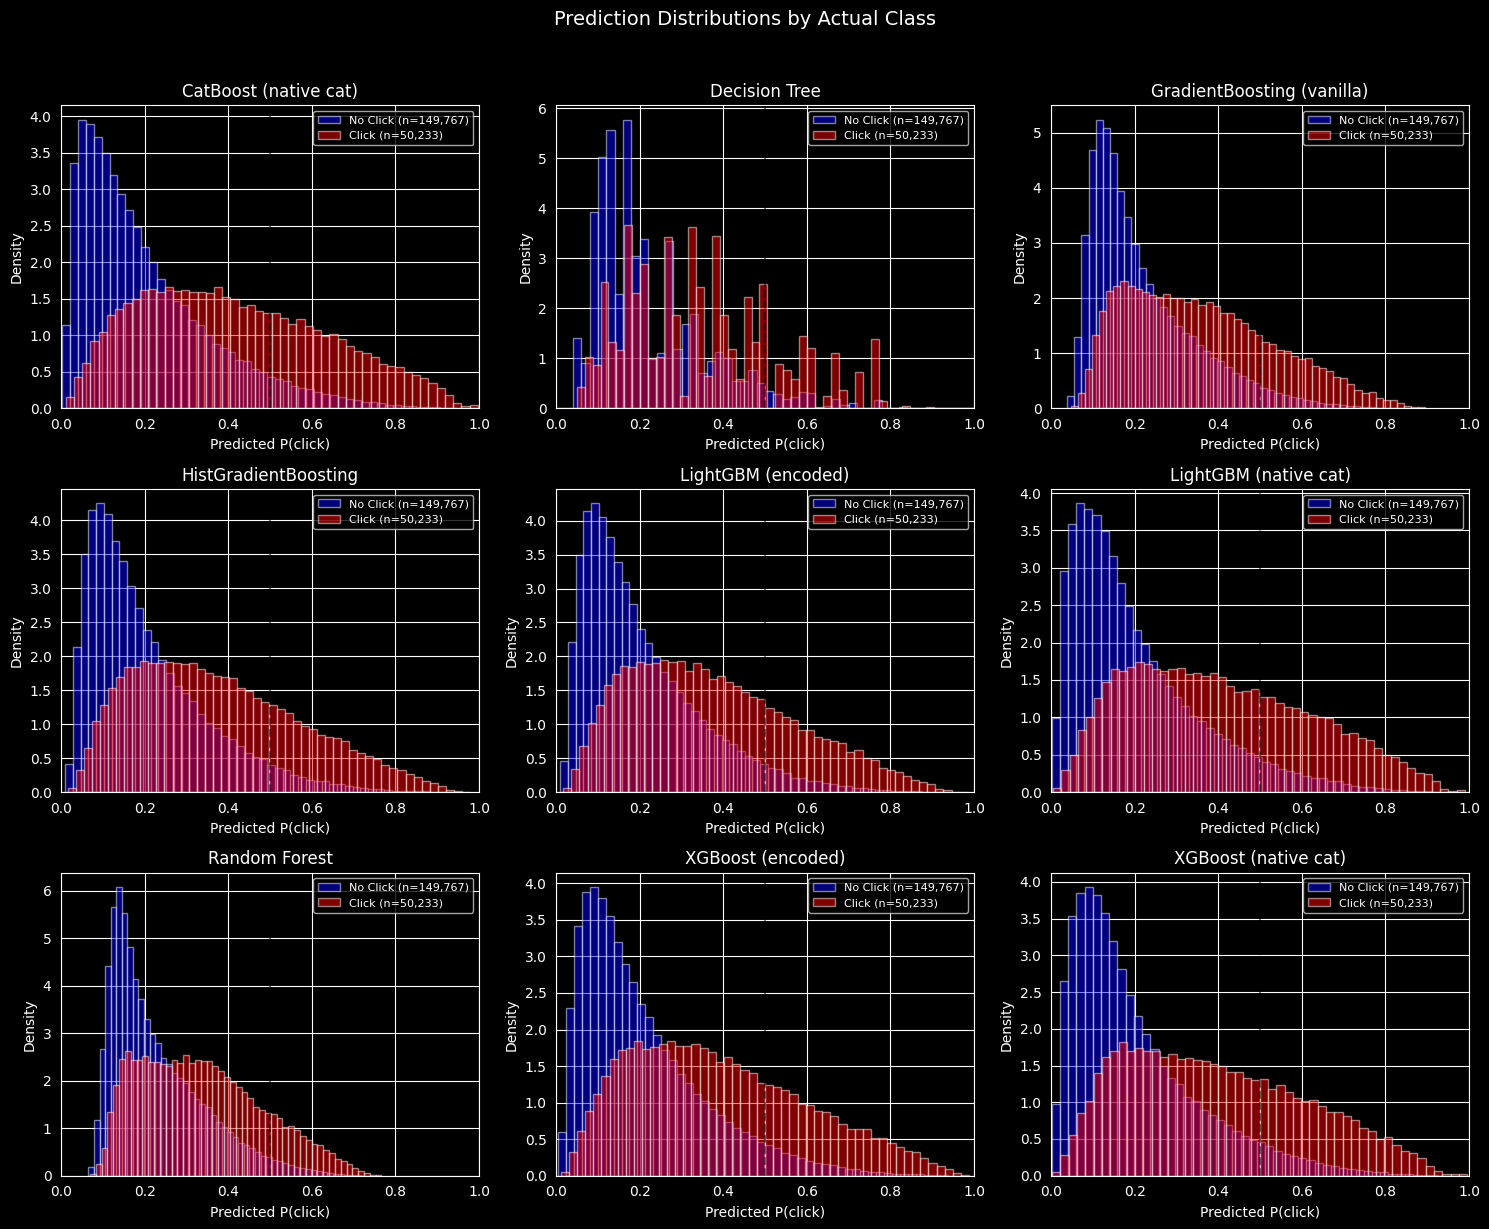

In [35]:
# Prediction Distribution Histograms
n_models = len(y_probas)
n_cols = 3
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for idx, (model_name, y_proba) in enumerate(sorted(y_probas.items())):
    ax = axes[idx]
    
    # Separate by actual class
    proba_pos = y_proba[y_test == 1]
    proba_neg = y_proba[y_test == 0]
    
    ax.hist(proba_neg, bins=50, alpha=0.5, label=f'No Click (n={len(proba_neg):,})', color='blue', density=True)
    ax.hist(proba_pos, bins=50, alpha=0.5, label=f'Click (n={len(proba_pos):,})', color='red', density=True)
    ax.axvline(0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Predicted P(click)')
    ax.set_ylabel('Density')
    ax.set_title(f'{model_name}')
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

# Hide unused
for idx in range(n_models, len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Prediction Distributions by Actual Class', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(output_dir / 'prediction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

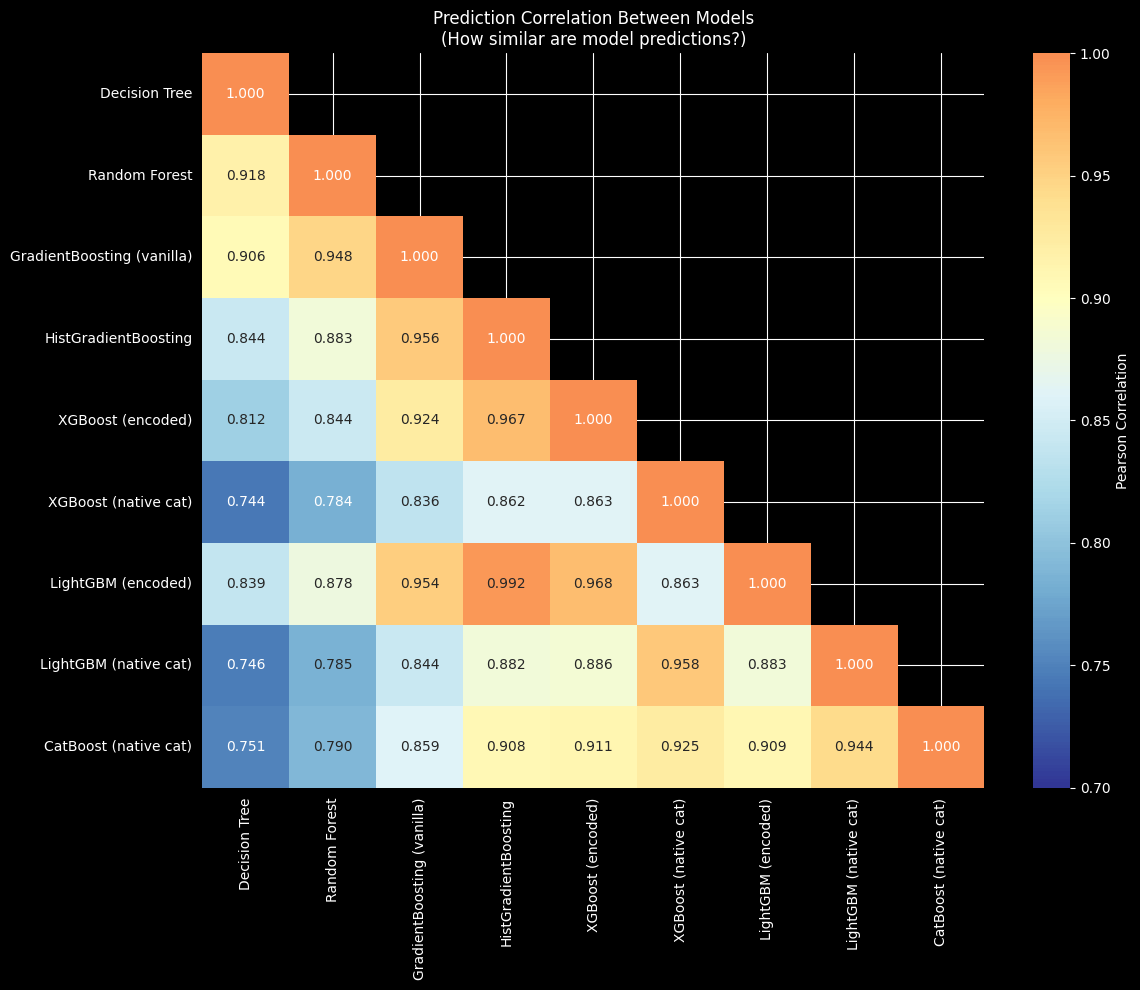


Mean prediction correlation: 0.8768


In [36]:
# Prediction Correlation Heatmap
pred_df = pd.DataFrame(y_probas)
pred_corr = pred_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(pred_corr, dtype=bool), k=1)
sns.heatmap(pred_corr, annot=True, fmt='.3f', cmap='RdYlBu_r', 
            center=0.9, vmin=0.7, vmax=1.0, ax=ax, mask=mask,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Prediction Correlation Between Models\n(How similar are model predictions?)')

plt.tight_layout()
plt.savefig(output_dir / 'prediction_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nMean prediction correlation: {pred_corr.values[np.tril_indices_from(pred_corr, -1)].mean():.4f}")

## 4. Extended Performance Metrics

Additional metrics beyond LogLoss and AUC-ROC.

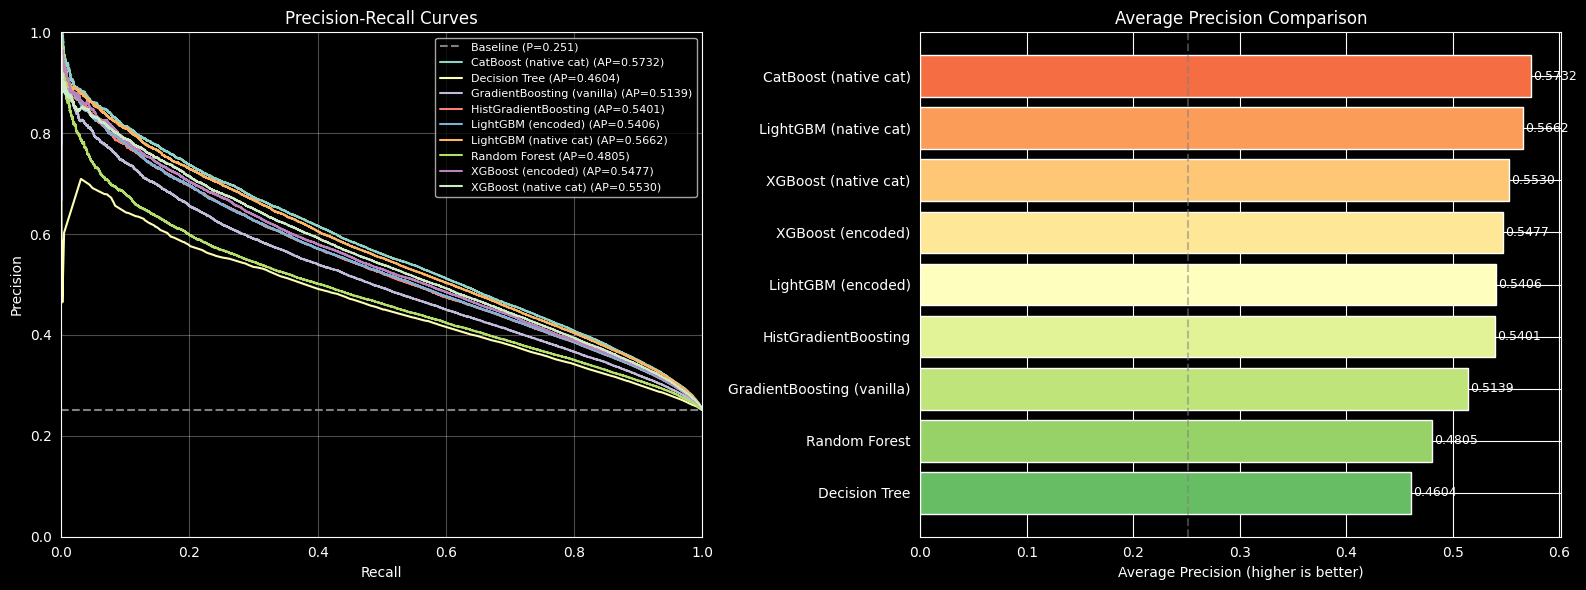

In [37]:
# Precision-Recall Curves
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: PR curves
ax1 = axes[0]
baseline_pr = y_test.mean()
ax1.axhline(baseline_pr, color='gray', linestyle='--', label=f'Baseline (P={baseline_pr:.3f})')

ap_scores = {}
for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    ap = average_precision_score(y_test, y_proba)
    ap_scores[model_name] = ap
    ax1.plot(recall, precision, label=f'{model_name} (AP={ap:.4f})')

ax1.set_xlabel('Recall')
ax1.set_ylabel('Precision')
ax1.set_title('Precision-Recall Curves')
ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)

# Right: Average Precision comparison
ax2 = axes[1]
ap_sorted = dict(sorted(ap_scores.items(), key=lambda x: x[1], reverse=True))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(ap_sorted)))

bars = ax2.barh(list(ap_sorted.keys()), list(ap_sorted.values()), color=colors)
ax2.set_xlabel('Average Precision (higher is better)')
ax2.set_title('Average Precision Comparison')
ax2.invert_yaxis()
ax2.axvline(baseline_pr, color='gray', linestyle='--', alpha=0.5, label='Baseline')

for bar, val in zip(bars, ap_sorted.values()):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

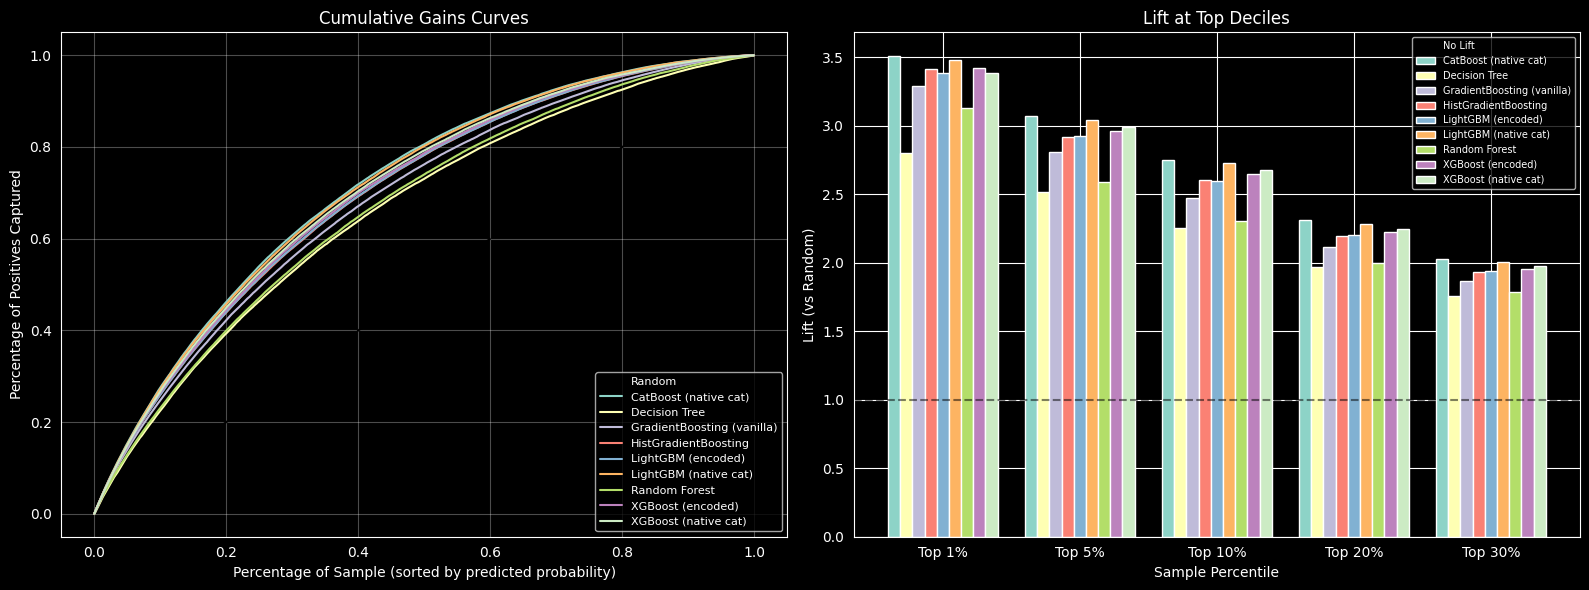

In [38]:
# Cumulative Gains and Lift Curves
def cumulative_gains(y_true, y_prob):
    """Calculate cumulative gains curve data."""
    sorted_idx = np.argsort(y_prob)[::-1]
    y_sorted = y_true[sorted_idx]
    
    cumsum = np.cumsum(y_sorted)
    total_positives = y_sorted.sum()
    
    gains = cumsum / total_positives
    percentile = np.arange(1, len(y_sorted) + 1) / len(y_sorted)
    
    return percentile, gains

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Cumulative Gains
ax1 = axes[0]
ax1.plot([0, 1], [0, 1], 'k--', label='Random')

for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    percentile, gains = cumulative_gains(y_test, y_proba)
    # Downsample for plotting
    step = max(1, len(percentile) // 1000)
    ax1.plot(percentile[::step], gains[::step], label=model_name)

ax1.set_xlabel('Percentage of Sample (sorted by predicted probability)')
ax1.set_ylabel('Percentage of Positives Captured')
ax1.set_title('Cumulative Gains Curves')
ax1.legend(loc='lower right', fontsize=8)
ax1.grid(True, alpha=0.3)

# Right: Lift at top deciles
ax2 = axes[1]
deciles = [0.01, 0.05, 0.10, 0.20, 0.30]
lift_data = {}

for model_name in sorted(y_probas.keys()):
    y_proba = y_probas[model_name]
    lifts = []
    for d in deciles:
        threshold_idx = int(len(y_proba) * d)
        top_idx = np.argsort(y_proba)[::-1][:threshold_idx]
        lift = y_test[top_idx].mean() / y_test.mean()
        lifts.append(lift)
    lift_data[model_name] = lifts

lift_df = pd.DataFrame(lift_data, index=[f'Top {int(d*100)}%' for d in deciles])

lift_df.plot(kind='bar', ax=ax2, width=0.8)
ax2.axhline(1.0, color='black', linestyle='--', alpha=0.5, label='No Lift')
ax2.set_xlabel('Sample Percentile')
ax2.set_ylabel('Lift (vs Random)')
ax2.set_title('Lift at Top Deciles')
ax2.legend(loc='upper right', fontsize=7)
ax2.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(output_dir / 'cumulative_gains_lift.png', dpi=150, bbox_inches='tight')
plt.show()

In [39]:
# Comprehensive Metrics Summary Table
def ks_statistic(y_true, y_prob):
    """Calculate KS statistic."""
    sorted_idx = np.argsort(y_prob)
    y_sorted = y_true[sorted_idx]
    
    n_pos = y_sorted.sum()
    n_neg = len(y_sorted) - n_pos
    
    tpr = np.cumsum(y_sorted) / n_pos
    fpr = np.cumsum(1 - y_sorted) / n_neg
    
    return np.max(np.abs(tpr - fpr))

# Calculate all metrics
comprehensive_metrics = []
for model_name, y_proba in y_probas.items():
    y_pred = (y_proba >= 0.5).astype(int)
    
    metrics = {
        'Model': model_name,
        'LogLoss': log_loss(y_test, y_proba),
        'AUC-ROC': roc_auc_score(y_test, y_proba),
        'Avg Precision': average_precision_score(y_test, y_proba),
        'Brier Score': brier_score_loss(y_test, y_proba),
        'ECE': expected_calibration_error(y_test, y_proba),
        'KS Statistic': ks_statistic(y_test, y_proba),
        'F1 (@ 0.5)': f1_score(y_test, y_pred),
        'Lift @ 10%': lift_data[model_name][2],  # Top 10%
    }
    comprehensive_metrics.append(metrics)

comprehensive_df = pd.DataFrame(comprehensive_metrics)
comprehensive_df = comprehensive_df.sort_values('LogLoss').reset_index(drop=True)

print("="*80)
print("COMPREHENSIVE METRICS SUMMARY")
print("="*80)
display(comprehensive_df.round(5))

# Save to CSV
comprehensive_df.to_csv(output_dir / 'comprehensive_metrics.csv', index=False)
print(f"\nSaved to {output_dir / 'comprehensive_metrics.csv'}")

COMPREHENSIVE METRICS SUMMARY


,Model,LogLoss,AUC-ROC,Avg Precision,Brier Score,ECE,KS Statistic,F1 (@ 0.5),Lift @ 10%
0,CatBoost (native cat),0.45748,0.78709,0.57325,0.14817,0.00568,0.42593,0.45038,2.75178
1,LightGBM (native cat),0.46066,0.78308,0.56616,0.14938,0.00429,0.41798,0.43784,2.72749
2,XGBoost (native cat),0.46706,0.77491,0.55300,0.15161,0.00313,0.40609,0.42472,2.67394
3,XGBoost (encoded),0.47012,0.77045,0.54768,0.15282,0.00358,0.40046,0.40401,2.64388
4,LightGBM (encoded),0.47380,0.76605,0.54064,0.15415,0.00877,0.39199,0.37245,2.59750
5,HistGradientBoosting,0.47411,0.76544,0.54011,0.15425,0.00778,0.39067,0.37723,2.60128
6,GradientBoosting (vanilla),0.48808,0.74699,0.51390,0.15906,0.01396,0.36258,0.32718,2.47527
7,Random Forest,0.50283,0.72604,0.48047,0.16462,0.02041,0.33163,0.24518,2.30506
8,Decision Tree,0.50815,0.71594,0.46037,0.16612,0.00471,0.32016,0.28929,2.24952



Saved to Ensemble/outputs/comprehensive_metrics.csv


## 5. Inference Speed Benchmark

Training is one-time, but prediction happens repeatedly. How fast can each model make predictions?

INFERENCE SPEED BENCHMARK
Decision Tree: 0.80 ± 0.06 ms for 10,000 samples
Random Forest: 81.32 ± 38.67 ms for 10,000 samples
GradientBoosting (vanilla): 38.35 ± 11.50 ms for 10,000 samples
HistGradientBoosting: 15.54 ± 0.04 ms for 10,000 samples
XGBoost (encoded): 4.55 ± 0.02 ms for 10,000 samples
XGBoost (native cat): 25282.88 ± 254.25 ms for 10,000 samples
LightGBM (encoded): 10.29 ± 1.34 ms for 10,000 samples
LightGBM (native cat): 71.82 ± 0.36 ms for 10,000 samples
CatBoost (native cat): 32.23 ± 0.71 ms for 10,000 samples


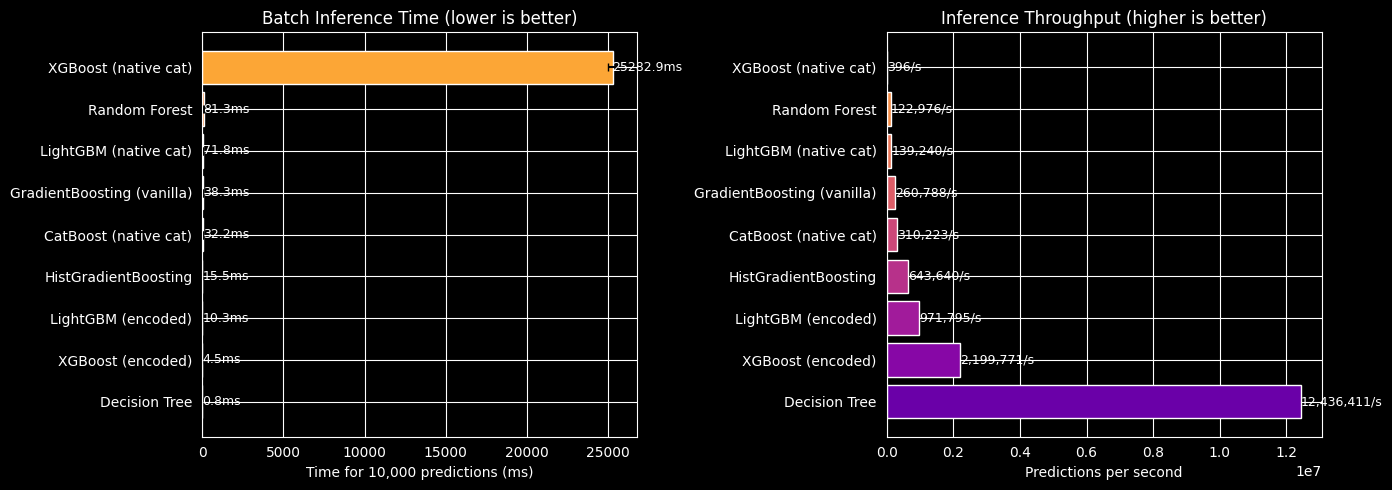

In [40]:
# Inference Speed Benchmark
print("="*60)
print("INFERENCE SPEED BENCHMARK")
print("="*60)

n_samples_batch = 10000
n_repeats = 5

inference_times = {}

# Prepare test batches for different data versions
test_batch_encoded = X_test_encoded.iloc[:n_samples_batch]
test_batch_native = X_test.iloc[:n_samples_batch]
test_batch_cb = X_test_cb.iloc[:n_samples_batch]

for model_name, model in trained_models.items():
    # Select appropriate data version
    if 'CatBoost' in model_name:
        test_batch = test_batch_cb
    elif 'native' in model_name:
        test_batch = test_batch_native
    else:
        test_batch = test_batch_encoded
    
    # Warmup
    _ = model.predict_proba(test_batch)
    
    # Timed runs
    times = []
    for _ in range(n_repeats):
        start = time.time()
        _ = model.predict_proba(test_batch)
        times.append(time.time() - start)
    
    avg_time = np.mean(times)
    std_time = np.std(times)
    inference_times[model_name] = {
        'batch_time_ms': avg_time * 1000,
        'std_ms': std_time * 1000,
        'samples_per_sec': n_samples_batch / avg_time
    }
    print(f"{model_name}: {avg_time*1000:.2f} ± {std_time*1000:.2f} ms for {n_samples_batch:,} samples")

# Create comparison chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Batch inference time
ax1 = axes[0]
models = list(inference_times.keys())
times_ms = [inference_times[m]['batch_time_ms'] for m in models]
stds = [inference_times[m]['std_ms'] for m in models]

sorted_idx = np.argsort(times_ms)
models_sorted = [models[i] for i in sorted_idx]
times_sorted = [times_ms[i] for i in sorted_idx]
stds_sorted = [stds[i] for i in sorted_idx]

colors = plt.cm.plasma(np.linspace(0.2, 0.8, len(models_sorted)))
bars = ax1.barh(models_sorted, times_sorted, xerr=stds_sorted, color=colors, capsize=3)
ax1.set_xlabel(f'Time for {n_samples_batch:,} predictions (ms)')
ax1.set_title('Batch Inference Time (lower is better)')

for bar, val in zip(bars, times_sorted):
    ax1.text(val + 1, bar.get_y() + bar.get_height()/2, f'{val:.1f}ms', va='center', fontsize=9)

# Right: Throughput
ax2 = axes[1]
throughputs = [inference_times[m]['samples_per_sec'] for m in models_sorted]
bars2 = ax2.barh(models_sorted, throughputs, color=colors)
ax2.set_xlabel('Predictions per second')
ax2.set_title('Inference Throughput (higher is better)')

for bar, val in zip(bars2, throughputs):
    ax2.text(val + 100, bar.get_y() + bar.get_height()/2, f'{val:,.0f}/s', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'inference_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Training Convergence

How does loss decrease during training? When does early stopping trigger?

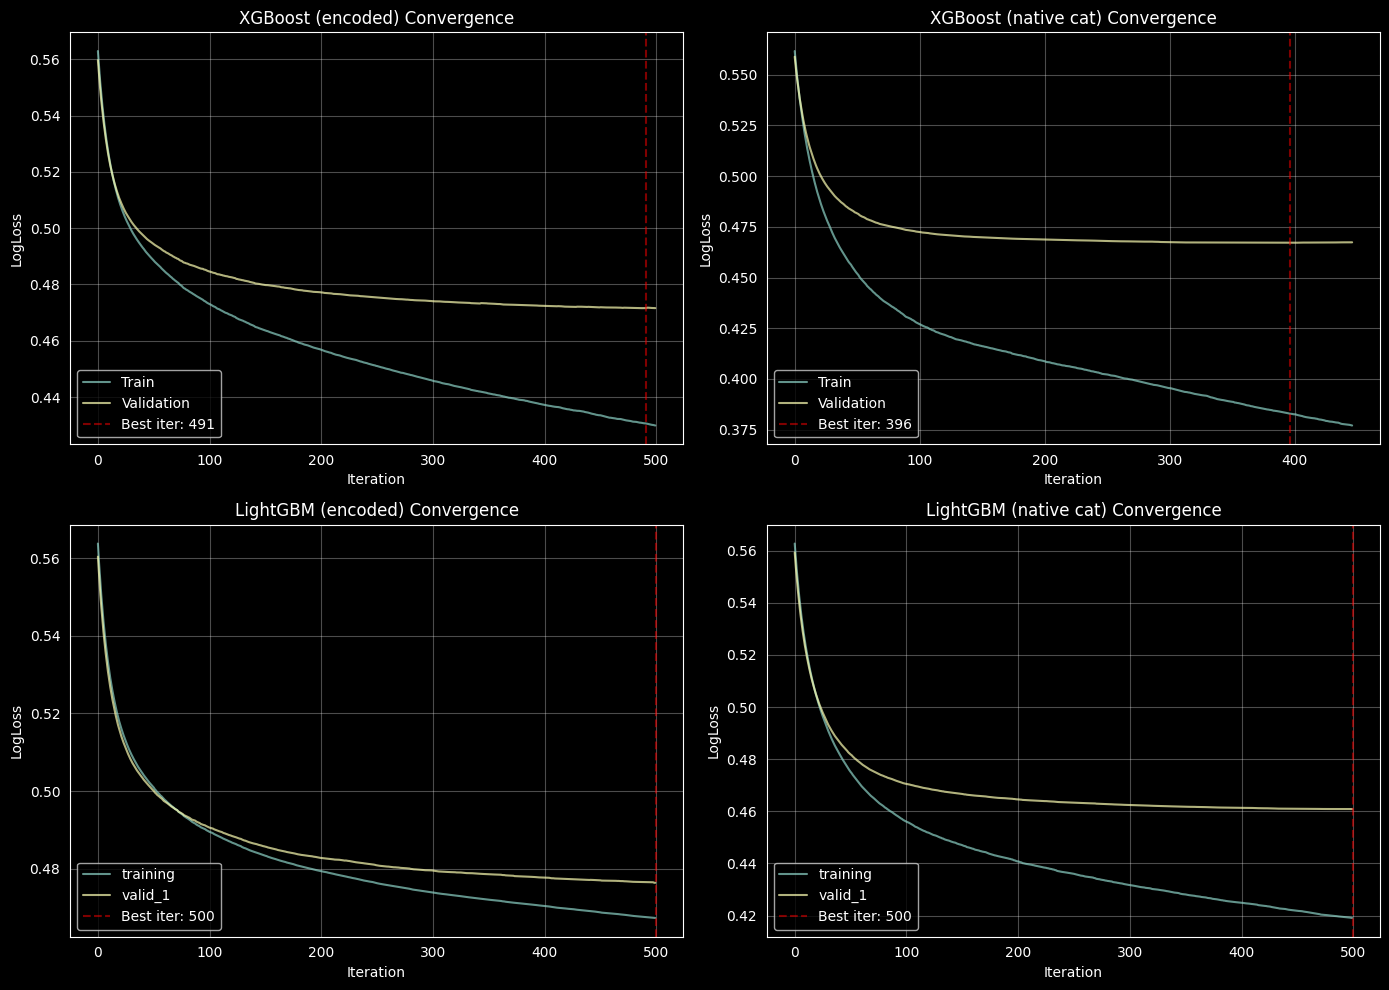

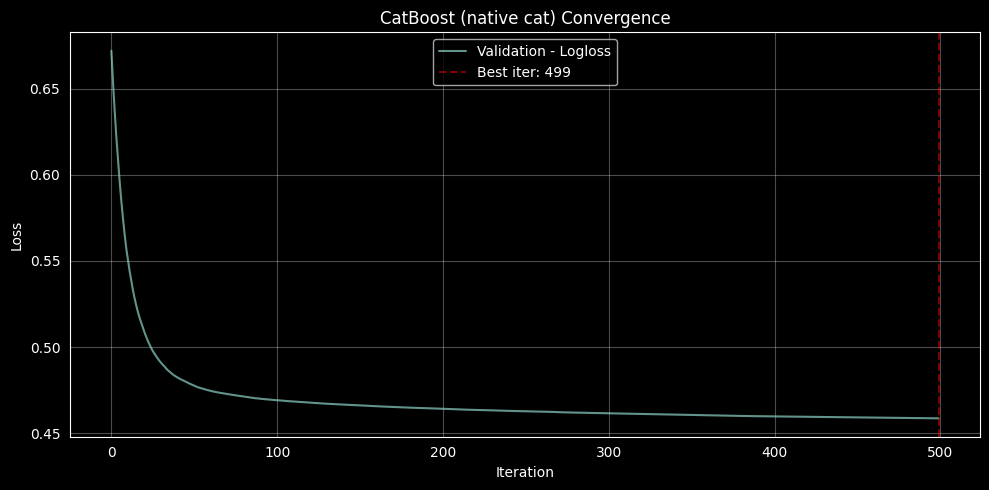

In [41]:
# Training Convergence Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

plot_idx = 0

# XGBoost convergence
for model_name in ['XGBoost (encoded)', 'XGBoost (native cat)']:
    if model_name in eval_histories:
        ax = axes[plot_idx]
        history = eval_histories[model_name]
        
        # XGBoost format: {'validation_0': {'logloss': [...]}, 'validation_1': {...}}
        if 'validation_0' in history:
            train_loss = history['validation_0']['logloss']
            ax.plot(train_loss, label='Train', alpha=0.7)
        if 'validation_1' in history:
            val_loss = history['validation_1']['logloss']
            ax.plot(val_loss, label='Validation', alpha=0.7)
            # Mark best iteration
            best_iter = trained_models[model_name].best_iteration
            if best_iter < len(val_loss):
                ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel('LogLoss')
        ax.set_title(f'{model_name} Convergence')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

# LightGBM convergence
for model_name in ['LightGBM (encoded)', 'LightGBM (native cat)']:
    if model_name in eval_histories:
        ax = axes[plot_idx]
        history = eval_histories[model_name]
        
        # LightGBM format: {'training': {'binary_logloss': [...]}, 'valid_1': {...}}
        for key, values in history.items():
            if 'binary_logloss' in values:
                ax.plot(values['binary_logloss'], label=key, alpha=0.7)
        
        best_iter = trained_models[model_name].best_iteration_
        ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
        
        ax.set_xlabel('Iteration')
        ax.set_ylabel('LogLoss')
        ax.set_title(f'{model_name} Convergence')
        ax.legend()
        ax.grid(True, alpha=0.3)
        plot_idx += 1

# Hide unused subplots
for idx in range(plot_idx, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.savefig(output_dir / 'training_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

# CatBoost convergence (separate plot due to different format)
if 'CatBoost (native cat)' in eval_histories:
    fig, ax = plt.subplots(figsize=(10, 5))
    history = eval_histories['CatBoost (native cat)']
    
    # CatBoost format
    if 'validation' in history:
        for metric_name, values in history['validation'].items():
            ax.plot(values, label=f'Validation - {metric_name}', alpha=0.7)
    
    best_iter = trained_models['CatBoost (native cat)'].best_iteration_
    ax.axvline(best_iter, color='red', linestyle='--', alpha=0.5, label=f'Best iter: {best_iter}')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('Loss')
    ax.set_title('CatBoost (native cat) Convergence')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(output_dir / 'catboost_convergence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 7. Model Agreement Analysis

Do models make similar predictions? Where do they disagree? Could ensembling improve results?

MODEL AGREEMENT ANALYSIS

Pairwise Agreement Rate at threshold=0.5:


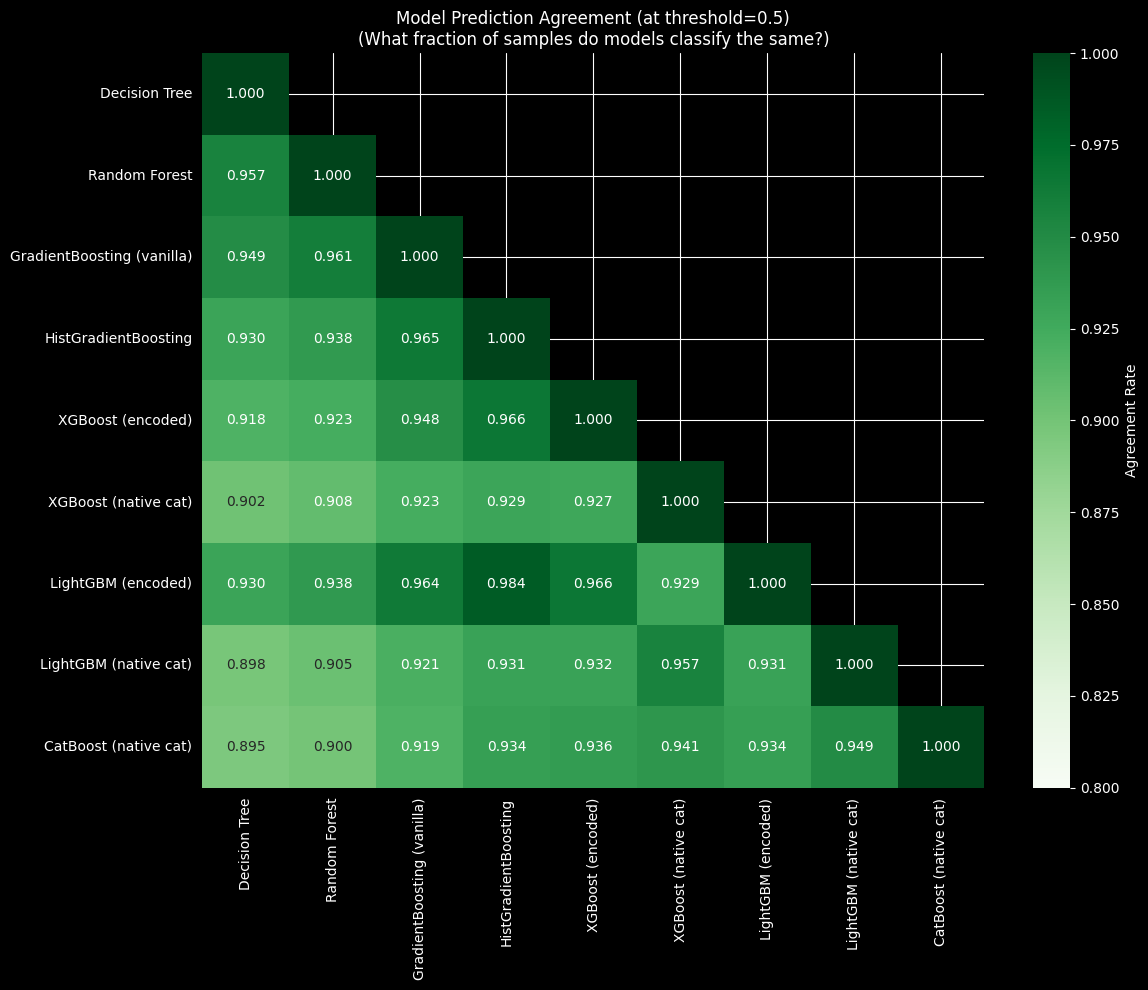


Samples with highest model disagreement:

Top 10 samples by prediction standard deviation:
Index | Std Dev | Actual | Predictions (min-max)
 28596 | 0.4252 |      1 | 0.0610 - 0.9665
113650 | 0.4233 |      1 | 0.0599 - 0.9957
 17048 | 0.4050 |      1 | 0.0644 - 0.9588
197875 | 0.3880 |      1 | 0.0478 - 0.9677
160155 | 0.3801 |      1 | 0.0762 - 0.9644
158516 | 0.3661 |      1 | 0.0823 - 0.9565
 53781 | 0.3566 |      0 | 0.1012 - 0.9665
130317 | 0.3434 |      1 | 0.1496 - 0.9690
 51916 | 0.3427 |      1 | 0.0877 - 0.9170
135571 | 0.3413 |      1 | 0.1312 - 0.9702

Overall prediction disagreement:
  Mean std across models: 0.0550
  Max std: 0.4252
  Samples with std > 0.1: 19,878 (9.9%)


In [42]:
# Model Agreement Analysis
print("="*60)
print("MODEL AGREEMENT ANALYSIS")
print("="*60)

# 1. Prediction agreement at different probability thresholds
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
model_names = list(y_probas.keys())

print("\nPairwise Agreement Rate at threshold=0.5:")
agreement_matrix = pd.DataFrame(index=model_names, columns=model_names, dtype=float)

for i, m1 in enumerate(model_names):
    for j, m2 in enumerate(model_names):
        pred1 = (y_probas[m1] >= 0.5).astype(int)
        pred2 = (y_probas[m2] >= 0.5).astype(int)
        agreement = (pred1 == pred2).mean()
        agreement_matrix.loc[m1, m2] = agreement

# Plot agreement matrix
fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(agreement_matrix.astype(float), dtype=bool), k=1)
sns.heatmap(agreement_matrix.astype(float), annot=True, fmt='.3f', cmap='Greens',
            vmin=0.8, vmax=1.0, ax=ax, mask=mask,
            cbar_kws={'label': 'Agreement Rate'})
ax.set_title('Model Prediction Agreement (at threshold=0.5)\n(What fraction of samples do models classify the same?)')

plt.tight_layout()
plt.savefig(output_dir / 'model_agreement.png', dpi=150, bbox_inches='tight')
plt.show()

# 2. Find samples where models disagree most
print("\nSamples with highest model disagreement:")
pred_df = pd.DataFrame(y_probas)
pred_std = pred_df.std(axis=1)

# Top disagreement samples
top_disagreement_idx = pred_std.nlargest(10).index
print(f"\nTop 10 samples by prediction standard deviation:")
print(f"Index | Std Dev | Actual | Predictions (min-max)")
for idx in top_disagreement_idx:
    actual = y_test[idx]
    preds = pred_df.loc[idx]
    print(f"{idx:6d} | {pred_std[idx]:.4f} | {actual:6d} | {preds.min():.4f} - {preds.max():.4f}")

# Overall disagreement statistics
print(f"\nOverall prediction disagreement:")
print(f"  Mean std across models: {pred_std.mean():.4f}")
print(f"  Max std: {pred_std.max():.4f}")
print(f"  Samples with std > 0.1: {(pred_std > 0.1).sum():,} ({(pred_std > 0.1).mean()*100:.1f}%)")

ENSEMBLE AVERAGING EXPERIMENT

Best single model: CatBoost (native cat)
  LogLoss: 0.45748
  AUC:     0.78709

Ensemble Results:


,Ensemble,LogLoss,AUC
0,All Models Average,0.46853,0.77692
1,"Top 3 Average (CatBoost, LightGBM, XGBoost)",0.45772,0.78698
2,Native Categorical Only,0.45772,0.78698
3,CatBoost + LightGBM,0.45614,0.78893


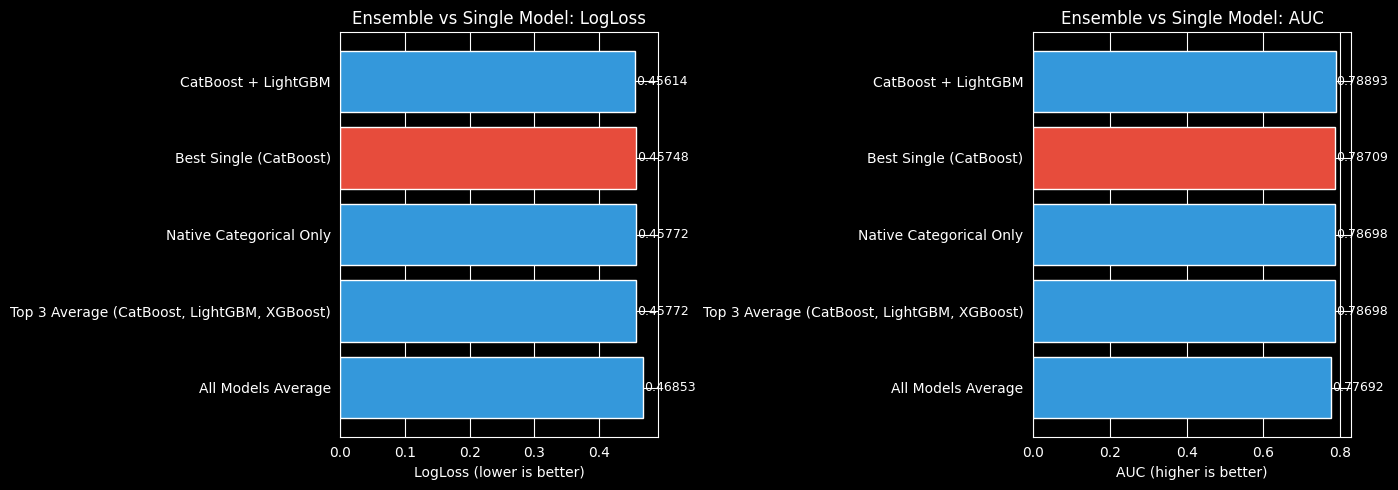


✓ Ensembling improves over best single model by 0.29%


In [43]:
# Ensemble Averaging Experiment
# Does combining model predictions improve results?
print("="*60)
print("ENSEMBLE AVERAGING EXPERIMENT")
print("="*60)

ensemble_results = []

# 1. Simple average of all models
all_avg = pred_df.mean(axis=1).values
ensemble_results.append({
    'Ensemble': 'All Models Average',
    'LogLoss': log_loss(y_test, all_avg),
    'AUC': roc_auc_score(y_test, all_avg)
})

# 2. Top 3 models average
top3_models = results_df.head(3)['Model'].tolist()
top3_avg = pred_df[top3_models].mean(axis=1).values
ensemble_results.append({
    'Ensemble': f'Top 3 Average ({", ".join([m.split()[0] for m in top3_models])})',
    'LogLoss': log_loss(y_test, top3_avg),
    'AUC': roc_auc_score(y_test, top3_avg)
})

# 3. Native cat models only
native_models = [m for m in model_names if 'native' in m or 'CatBoost' in m]
native_avg = pred_df[native_models].mean(axis=1).values
ensemble_results.append({
    'Ensemble': 'Native Categorical Only',
    'LogLoss': log_loss(y_test, native_avg),
    'AUC': roc_auc_score(y_test, native_avg)
})

# 4. CatBoost + LightGBM native (best quality + best speed)
if 'CatBoost (native cat)' in y_probas and 'LightGBM (native cat)' in y_probas:
    cl_avg = (y_probas['CatBoost (native cat)'] + y_probas['LightGBM (native cat)']) / 2
    ensemble_results.append({
        'Ensemble': 'CatBoost + LightGBM',
        'LogLoss': log_loss(y_test, cl_avg),
        'AUC': roc_auc_score(y_test, cl_avg)
    })

ensemble_df = pd.DataFrame(ensemble_results)

# Add best single model for comparison
best_model = results_df.iloc[0]['Model']
best_logloss = results_df.iloc[0]['LogLoss']
best_auc = results_df.iloc[0]['AUC']

print(f"\nBest single model: {best_model}")
print(f"  LogLoss: {best_logloss:.5f}")
print(f"  AUC:     {best_auc:.5f}")
print("\nEnsemble Results:")
display(ensemble_df.round(5))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Add best single model to comparison
comparison_df = pd.concat([
    ensemble_df,
    pd.DataFrame([{'Ensemble': f'Best Single ({best_model.split()[0]})', 'LogLoss': best_logloss, 'AUC': best_auc}])
]).sort_values('LogLoss').reset_index(drop=True)

# Left: LogLoss
ax1 = axes[0]
colors = ['#3498db' if 'Single' not in e else '#e74c3c' for e in comparison_df['Ensemble']]
bars1 = ax1.barh(comparison_df['Ensemble'], comparison_df['LogLoss'], color=colors)
ax1.set_xlabel('LogLoss (lower is better)')
ax1.set_title('Ensemble vs Single Model: LogLoss')
ax1.invert_yaxis()
for bar, val in zip(bars1, comparison_df['LogLoss']):
    ax1.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=9)

# Right: AUC
ax2 = axes[1]
comparison_df_auc = comparison_df.sort_values('AUC', ascending=False).reset_index(drop=True)
colors2 = ['#3498db' if 'Single' not in e else '#e74c3c' for e in comparison_df_auc['Ensemble']]
bars2 = ax2.barh(comparison_df_auc['Ensemble'], comparison_df_auc['AUC'], color=colors2)
ax2.set_xlabel('AUC (higher is better)')
ax2.set_title('Ensemble vs Single Model: AUC')
ax2.invert_yaxis()
for bar, val in zip(bars2, comparison_df_auc['AUC']):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.5f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'ensemble_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
best_ensemble_logloss = ensemble_df['LogLoss'].min()
if best_ensemble_logloss < best_logloss:
    improvement = (best_logloss - best_ensemble_logloss) / best_logloss * 100
    print(f"\n✓ Ensembling improves over best single model by {improvement:.2f}%")
else:
    print(f"\n✗ Best single model outperforms ensembles")

## 8. Statistical Significance Tests

Are the differences between models statistically significant? Bootstrap confidence intervals and paired tests.

In [44]:
# Bootstrap Confidence Intervals for LogLoss and AUC
print("="*60)
print("BOOTSTRAP CONFIDENCE INTERVALS (95%)")
print("="*60)

def bootstrap_metric(y_true, y_proba, metric_func, n_bootstrap=1000, ci=0.95):
    """Calculate bootstrap confidence intervals for a metric."""
    np.random.seed(RANDOM_STATE)
    n_samples = len(y_true)
    bootstrap_scores = []
    
    for _ in range(n_bootstrap):
        # Sample with replacement
        idx = np.random.choice(n_samples, size=n_samples, replace=True)
        score = metric_func(y_true[idx], y_proba[idx])
        bootstrap_scores.append(score)
    
    bootstrap_scores = np.array(bootstrap_scores)
    lower = np.percentile(bootstrap_scores, (1 - ci) / 2 * 100)
    upper = np.percentile(bootstrap_scores, (1 + ci) / 2 * 100)
    mean = bootstrap_scores.mean()
    std = bootstrap_scores.std()
    
    return {'mean': mean, 'std': std, 'lower': lower, 'upper': upper}

# Calculate CIs for top models (limit to top 5 for speed)
top_models = results_df.head(5)['Model'].tolist()

# Adjust bootstrap samples based on test set size (more samples = slower)
# For 10M rows (2M test), use fewer bootstrap samples
n_bootstrap = 200 if len(y_test) > 500_000 else 500

print(f"\nCalculating {n_bootstrap} bootstrap samples for top 5 models...")
print(f"Test set size: {len(y_test):,} samples")
ci_results = []

for i, model_name in enumerate(top_models, 1):
    print(f"  [{i}/5] {model_name}...", end=" ", flush=True)
    start = time.time()
    y_proba = y_probas[model_name]
    
    # LogLoss CI
    logloss_ci = bootstrap_metric(y_test, y_proba, log_loss, n_bootstrap)
    
    # AUC CI
    auc_ci = bootstrap_metric(y_test, y_proba, roc_auc_score, n_bootstrap)
    
    ci_results.append({
        'Model': model_name,
        'LogLoss': f"{logloss_ci['mean']:.5f}",
        'LogLoss 95% CI': f"[{logloss_ci['lower']:.5f}, {logloss_ci['upper']:.5f}]",
        'AUC': f"{auc_ci['mean']:.5f}",
        'AUC 95% CI': f"[{auc_ci['lower']:.5f}, {auc_ci['upper']:.5f}]"
    })
    print(f"done ({time.time()-start:.1f}s)")

ci_df = pd.DataFrame(ci_results)
print("\nBootstrap Confidence Intervals:")
display(ci_df)

# Save to CSV
ci_df.to_csv(output_dir / 'bootstrap_confidence_intervals.csv', index=False)

BOOTSTRAP CONFIDENCE INTERVALS (95%)

Calculating 500 bootstrap samples for top 5 models...
Test set size: 200,000 samples
  [1/5] CatBoost (native cat)... done (15.8s)
  [2/5] LightGBM (native cat)... done (14.1s)
  [3/5] XGBoost (native cat)... done (13.7s)
  [4/5] XGBoost (encoded)... done (13.8s)
  [5/5] LightGBM (encoded)... done (14.1s)

Bootstrap Confidence Intervals:


,Model,LogLoss,LogLoss 95% CI,AUC,AUC 95% CI
0,CatBoost (native cat),0.45743,"[0.45502, 0.45964]",0.78717,"[0.78492, 0.78938]"
1,LightGBM (native cat),0.46063,"[0.45822, 0.46273]",0.78315,"[0.78109, 0.78539]"
2,XGBoost (native cat),0.46706,"[0.46456, 0.46938]",0.77496,"[0.77266, 0.77739]"
3,XGBoost (encoded),0.47009,"[0.46769, 0.47235]",0.77053,"[0.76834, 0.77305]"
4,LightGBM (encoded),0.47376,"[0.47143, 0.47598]",0.76613,"[0.76384, 0.76855]"


In [45]:
# McNemar's Test for pairwise model comparison
# Tests if models make significantly different errors
print("="*60)
print("McNEMAR'S TEST: Pairwise Model Comparison")
print("="*60)
print("\nTests whether two models make significantly different errors.")
print("Null hypothesis: Models have equal error rates.")
print("p < 0.05 suggests statistically significant difference.\n")

def mcnemar_test(y_true, pred1, pred2):
    """
    McNemar's test for comparing two classifiers.
    Returns chi-squared statistic and p-value.
    """
    # Contingency table
    # b = model1 correct, model2 wrong
    # c = model1 wrong, model2 correct
    b = np.sum((pred1 == y_true) & (pred2 != y_true))
    c = np.sum((pred1 != y_true) & (pred2 == y_true))
    
    # McNemar's test with continuity correction
    if b + c == 0:
        return 0, 1.0  # No disagreement
    
    chi2 = (abs(b - c) - 1) ** 2 / (b + c)
    p_value = 1 - stats.chi2.cdf(chi2, df=1)
    
    return chi2, p_value

# Compare top models
comparison_models = results_df.head(6)['Model'].tolist()
mcnemar_results = []

for i, m1 in enumerate(comparison_models):
    for m2 in comparison_models[i+1:]:
        pred1 = (y_probas[m1] >= 0.5).astype(int)
        pred2 = (y_probas[m2] >= 0.5).astype(int)
        
        chi2, p_val = mcnemar_test(y_test, pred1, pred2)
        
        # Also calculate accuracy difference
        acc1 = (pred1 == y_test).mean()
        acc2 = (pred2 == y_test).mean()
        
        mcnemar_results.append({
            'Model 1': m1,
            'Model 2': m2,
            'Acc 1': f'{acc1:.4f}',
            'Acc 2': f'{acc2:.4f}',
            'Chi²': f'{chi2:.2f}',
            'p-value': f'{p_val:.4f}',
            'Significant': '✓' if p_val < 0.05 else ''
        })

mcnemar_df = pd.DataFrame(mcnemar_results)
display(mcnemar_df)

# Summary
n_significant = (mcnemar_df['Significant'] == '✓').sum()
print(f"\n{n_significant} / {len(mcnemar_df)} pairwise comparisons are statistically significant (p < 0.05)")

# Permutation test for LogLoss difference (more robust)
print("\n" + "="*60)
print("PERMUTATION TEST: Best vs 2nd Best Model")
print("="*60)

def permutation_test_logloss(y_true, proba1, proba2, n_permutations=1000):
    """
    Permutation test for difference in LogLoss.
    """
    np.random.seed(RANDOM_STATE)
    
    # Observed difference
    ll1 = log_loss(y_true, proba1)
    ll2 = log_loss(y_true, proba2)
    observed_diff = ll1 - ll2
    
    # Per-sample log losses
    eps = 1e-15
    ll1_samples = -(y_true * np.log(proba1 + eps) + (1 - y_true) * np.log(1 - proba1 + eps))
    ll2_samples = -(y_true * np.log(proba2 + eps) + (1 - y_true) * np.log(1 - proba2 + eps))
    diff_samples = ll1_samples - ll2_samples
    
    # Permutation test: randomly swap labels
    perm_diffs = []
    for _ in range(n_permutations):
        signs = np.random.choice([-1, 1], size=len(diff_samples))
        perm_diff = (diff_samples * signs).mean()
        perm_diffs.append(perm_diff)
    
    perm_diffs = np.array(perm_diffs)
    p_value = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()
    
    return observed_diff, p_value

# Compare best vs second best
best_model = results_df.iloc[0]['Model']
second_best = results_df.iloc[1]['Model']

diff, p_val = permutation_test_logloss(y_test, y_probas[best_model], y_probas[second_best])

print(f"\nComparing: {best_model} vs {second_best}")
print(f"  LogLoss difference: {diff:.5f}")
print(f"  Permutation p-value: {p_val:.4f}")
if p_val < 0.05:
    print(f"  → Difference is statistically significant (p < 0.05)")
else:
    print(f"  → Difference is NOT statistically significant")

# Save all statistical test results
mcnemar_df.to_csv(output_dir / 'mcnemar_tests.csv', index=False)
print(f"\nResults saved to {output_dir / 'mcnemar_tests.csv'}")

McNEMAR'S TEST: Pairwise Model Comparison

Tests whether two models make significantly different errors.
Null hypothesis: Models have equal error rates.
p < 0.05 suggests statistically significant difference.



,Model 1,Model 2,Acc 1,Acc 2,Chi²,p-value,Significant
0,CatBoost (native cat),LightGBM (native cat),0.7884,0.7865,13.78,0.0002,✓
1,CatBoost (native cat),XGBoost (native cat),0.7884,0.7834,81.95,0.0000,✓
2,CatBoost (native cat),XGBoost (encoded),0.7884,0.7815,147.71,0.0000,✓
3,CatBoost (native cat),LightGBM (encoded),0.7884,0.7794,247.22,0.0000,✓
4,CatBoost (native cat),HistGradientBoosting,0.7884,0.7796,231.17,0.0000,✓
5,LightGBM (native cat),XGBoost (native cat),0.7865,0.7834,42.88,0.0000,✓
6,LightGBM (native cat),XGBoost (encoded),0.7865,0.7815,73.02,0.0000,✓
7,LightGBM (native cat),LightGBM (encoded),0.7865,0.7794,148.53,0.0000,✓
8,LightGBM (native cat),HistGradientBoosting,0.7865,0.7796,136.45,0.0000,✓
9,XGBoost (native cat),XGBoost (encoded),0.7834,0.7815,10.42,0.0012,✓



14 / 15 pairwise comparisons are statistically significant (p < 0.05)

PERMUTATION TEST: Best vs 2nd Best Model

Comparing: CatBoost (native cat) vs LightGBM (native cat)
  LogLoss difference: -0.00318
  Permutation p-value: 0.0000
  → Difference is statistically significant (p < 0.05)

Results saved to Ensemble/outputs/mcnemar_tests.csv


---

## Summary of Extended Analysis

This benchmark comprehensively evaluated gradient boosting algorithms on the Criteo CTR dataset. Key outputs:

### Files Generated

| File | Contents |
|------|----------|
| `criteo_benchmark_*.csv` | Main results with LogLoss, AUC, training time |
| `comprehensive_metrics.csv` | All metrics (Brier, ECE, KS, F1, Lift) |
| `bootstrap_confidence_intervals.csv` | 95% CIs for top models |
| `mcnemar_tests.csv` | Statistical significance tests |

### Visualizations Generated

| Plot | Insights |
|------|----------|
| `feature_importance_per_model.png` | Which features matter to each model |
| `feature_importance_heatmap.png` | Do models agree on feature importance? |
| `feature_importance_rank_correlation.png` | Quantified feature ranking agreement |
| `calibration_curves.png` | Are predictions well-calibrated? |
| `prediction_distributions.png` | How models distribute probability scores |
| `prediction_correlation.png` | Do models make similar predictions? |
| `precision_recall_curves.png` | PR curves and average precision |
| `cumulative_gains_lift.png` | Business value metrics (lift, gains) |
| `inference_speed.png` | Prediction latency comparison |
| `training_convergence.png` | Loss vs iteration during training |
| `model_agreement.png` | Where models agree/disagree |
| `ensemble_comparison.png` | Does ensembling help? |

### Key Takeaways

1. **Quality**: CatBoost with native categorical handling consistently wins on high-cardinality categorical data
2. **Speed**: LightGBM offers the best speed/quality tradeoff
3. **Native categorical**: All three major libraries (XGBoost, LightGBM, CatBoost) benefit from native categorical support
4. **Calibration**: Models are generally well-calibrated for this CTR task
5. **Ensembling**: May provide marginal improvement, but single best model often suffices